In [1]:
!pip install torch transformers scikit-learn pandas numpy matplotlib plotly spacy
!python -m spacy download nl_core_news_sm
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install --upgrade "transformers[torch]"
!pip install tqdm
!pip install Datasets
!pip install seaborn

  Using cached numpy-2.3.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl (12.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.6 which is incompatible.


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     ---- ----------------------------------- 1.3/12.8 MB 5.2 MB/s eta 0:00:03
     -------- ------------------------------- 2.9/12.8 MB 6.2 MB/s eta 0:00:02
     -------------- ------------------------- 4.7/12.8 MB 6.8 MB/s eta 0:00:02
     -------------------- ------------------- 6.6/12.8 MB 7.3 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 7.6 MB/s eta 0:00:01
     ------------------------------ --------- 9.7/12.8 MB 7.5 MB/s eta 0:00:01
     ----------------------------------- ---- 11.5/12.8 MB 7.6 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 7.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('nl_core_news_sm')
Looking in indexes: https://download.pytorch.org

##Run LDAprecoding_script

In [20]:
#Run LDAprecoding_script

import json

config = {
    "USE_FOLDER": True,
    "SOURCE_FOLDER_PATH": "Policyarchive_text",
    "OUTPUT_FOLDER": "Corex_topicdata_policy_v6",
    "MODEL_FOLDER": "Corex_topicdata_Policy_v5",
    "FOLDER_MODE": False, # Set to True if you want to use simple mode
    "YEAR_FILTER": [2023,2023],
    "DOC_TYPES": ["beleidsnotas","convenanten","kamerstukken","brieven","besluiten","jaarverslagen","jaarplannen",],
    "SENTS_PER_CHUNK": 300,
    "CONFIDENCE_THRESHOLD": 0.0,
    "MIN_COSINE": 0.05,
}

with open("corex_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)




In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json
import os
from pathlib import Path

# ---- Set your folders here ----
OUTPUT_FOLDER = "Corex_topicdata_policy_v6"
MODEL_FOLDER = "Corex_topicdata_policy_v5"

RESULTS_CSV = os.path.join(OUTPUT_FOLDER, "chunk_topics_corex_assignments.csv")
TOPICDATA_JSON = os.path.join(MODEL_FOLDER, "lda_topicdata.json")

# --- Load results ---
# Define the correct column order you want
correct_columns = [
    'filename', 'filepath', 'document_type', 'year', 'chunk_num',
    'chunk_text', 'topic', 'cosine', 'cosine_weighted', 'topic_probs', 'topic_assigned'
]

df = pd.read_csv(RESULTS_CSV)

# Reorder columns as desired (will ignore missing columns if typo)
train_source = df[[col for col in correct_columns if col in df.columns]]

# --- Load topic names and wordlists ---
with open(TOPICDATA_JSON, "r", encoding="utf-8") as f:
    topicdata = json.load(f)
topic_names = topicdata["topic_names"]
topic_word_lists = topicdata["topic_word_lists"]

# Now `train_source` is your cleaned, standardized dataframe ready for analysis!
# Example: Save to CSV (optional)
# train_source.to_csv(os.path.join(OUTPUT_FOLDER, "chunk_topics_corex_assignments_cleaned.csv"), index=False)


In [38]:
print(train_source)
import ast

def all_false_from_str(val):
    # Convert string to list
    if isinstance(val, str):
        try:
            val = ast.literal_eval(val)
        except Exception:
            return False
    # Check if list and all values are False
    return isinstance(val, list) and all(v is False for v in val)

no_topic_df = train_source[train_source['topic_assigned'].apply(all_false_from_str)]

print(f"Chunks with NO topic assigned: {len(no_topic_df)}")



                                               filename  \
0     beslisnota-bij-kamerbrief-overzicht-bijzondere...   
1     beslisnota-bij-kamerbrief-jaarplan-2023-kw-car...   
2     beslisnota-bij-antwoorden-op-kamervragen-over-...   
3     beslisnota-bij-kamerbrief-overzicht-verdragen-...   
4     beslisnota-bij-kamerbrief-overzicht-bijzondere...   
...                                                 ...   
4712              openbaar-jaarverslag-mivd-2022.51.txt   
4713              openbaar-jaarverslag-mivd-2022.49.txt   
4714               openbaar-jaarverslag-mivd-2022.8.txt   
4715               openbaar-jaarverslag-mivd-2022.7.txt   
4716               openbaar-jaarverslag-mivd-2022.9.txt   

                                               filepath  document_type  year  \
0     Policyarchive_text\beleidsnotas\2023\beslisnot...   beleidsnotas  2023   
1     Policyarchive_text\beleidsnotas\2023\beslisnot...   beleidsnotas  2023   
2     Policyarchive_text\beleidsnotas\2023\beslisno

In [39]:
# Suppose your column is a list of cosines per topic
import numpy as np
import ast

all_cosines = np.concatenate(train_source['cosine_weighted'].apply(ast.literal_eval).values)
print("Weighted cosine stats (all topics, all chunks):")
print(f"Min: {all_cosines.min():.3f}  Max: {all_cosines.max():.3f}  Median: {np.median(all_cosines):.3f}  90th pct: {np.percentile(all_cosines, 90):.3f}")


Weighted cosine stats (all topics, all chunks):
Min: 0.000  Max: 0.616  Median: 0.021  90th pct: 0.127


In [40]:
import numpy as np
import pandas as pd

# ========== USER CONFIG =============
COSINE_WEIGHTED_THRESHOLD = 0.01     # e.g. 0.1 or None
COSINE_THRESHOLD = 0.2             # e.g. 0.1 or None
BEST_MATCH_ON = "none"                # Options: None, "weighted", "simple", "either"
# None = include all topic matches (with filtering), otherwise only the topic with max cosine
# ====================================

# You must set:
# topic_names = [...]
# topic_word_lists = [...]

df = train_source.copy()

def parse_topic_list(val):
    if pd.isna(val) or val is None or val == '':
        return []
    if isinstance(val, list):
        return val
    # If comma-separated string
    return [t.strip() for t in str(val).split('|') if t.strip()]

def parse_weighted_cosines(val):
    if isinstance(val, list):
        return val
    if pd.isna(val) or val is None or val == '':
        return []
    try:
        import ast
        v = ast.literal_eval(str(val))
        if isinstance(v, list):
            return v
        return [float(v)]
    except:
        try:
            return [float(val)]
        except:
            return []
        
def parse_simple_cosine(val):
    try:
        return float(val)
    except:
        return 0.0

# --- Main logic ---
summary_rows = []

for t_idx, t in enumerate(topic_names):
    rows_for_topic = []
    for i, row in df.iterrows():
        topics = parse_topic_list(row['topic'])
        if t not in topics:
            continue
        
        # Best match selection if requested
        weighted_cosines = parse_weighted_cosines(row['cosine_weighted'])
        simple_cos = parse_simple_cosine(row['cosine'])
        this_weighted = weighted_cosines[t_idx] if t_idx < len(weighted_cosines) else None
        
        # Best match logic
        if BEST_MATCH_ON:
            idx_max_w = np.argmax(weighted_cosines) if weighted_cosines else -1
            idx_max_s = None
            if isinstance(row['topic_probs'], list) and len(row['topic_probs']) == len(topic_names):
                idx_max_s = np.argmax(row['topic_probs'])
            elif isinstance(row['topic_probs'], str):
                try:
                    import ast
                    probs = ast.literal_eval(row['topic_probs'])
                    if isinstance(probs, list) and len(probs) == len(topic_names):
                        idx_max_s = np.argmax(probs)
                except:
                    pass
            if BEST_MATCH_ON == "weighted" and t_idx != idx_max_w:
                continue
            if BEST_MATCH_ON == "simple" and idx_max_s is not None and t_idx != idx_max_s:
                continue
            if BEST_MATCH_ON == "either" and not (t_idx == idx_max_w or (idx_max_s is not None and t_idx == idx_max_s)):
                continue

        # Filter logic
        if COSINE_WEIGHTED_THRESHOLD is not None:
            if this_weighted is None or this_weighted < COSINE_WEIGHTED_THRESHOLD:
                continue
        if COSINE_THRESHOLD is not None:
            if simple_cos < COSINE_THRESHOLD:
                continue
        rows_for_topic.append((i, row, this_weighted, simple_cos))
    
    sub = df.loc[[i for i,_,_,_ in rows_for_topic]] if rows_for_topic else pd.DataFrame(columns=df.columns)

    # Averages and top file
    avg_5w_len = sub['chunk_text'].apply(lambda txt: sum(max(1, len(w)//5) for w in str(txt).split())).mean() if not sub.empty else np.nan
    avg_weighted_cosine = np.mean([cw for _,_,cw,_ in rows_for_topic if cw is not None]) if rows_for_topic else np.nan
    avg_simple_cosine = np.mean([cs for _,_,_,cs in rows_for_topic if cs is not None]) if rows_for_topic else np.nan

    # Keywords in chunk
    def count_topic_keywords(chunk):
        chunk_tokens = set(str(chunk).lower().split())
        anchors = set(topic_word_lists[t_idx])
        return len(chunk_tokens & anchors)
    avg_keywords = sub['chunk_text'].apply(count_topic_keywords).mean() if not sub.empty else np.nan

    file_counts = sub['filename'].value_counts()
    top_file = file_counts.idxmax() if not file_counts.empty else None
    top_file_count = file_counts.max() if not file_counts.empty else 0

    summary_rows.append({
        "topic": t,
        "avg_5w_len": avg_5w_len,
        "avg_weighted_cosine": avg_weighted_cosine,
        "avg_simple_cosine": avg_simple_cosine,
        "avg_keywords": avg_keywords,
        "top_file": top_file,
        "top_file_count": top_file_count,
        "total_chunks": len(sub),
        "rows_for_topic": rows_for_topic  # Store for later use if needed
    })

summary = pd.DataFrame(summary_rows)
print("\n--- SUMMARY TABLE (multi-label, with filtering/best match) ---\n", summary)


# After the loop, create and save the filtered dataframe:
summary = pd.DataFrame(summary_rows)
print("\n--- SUMMARY TABLE (multi-label, with filtering/best match) ---\n", summary)


filtered_rows = []
for i, row in df.iterrows():
    # Parse columns if needed (if they are strings in CSV)
    topics = parse_topic_list(row['topic'])
    weighted_cosines = parse_weighted_cosines(row['cosine_weighted'])
    topic_assigned = ast.literal_eval(row['topic_assigned']) if isinstance(row['topic_assigned'], str) else row['topic_assigned']
    include = False

    # Case 1: No topic assigned at all
    if isinstance(topic_assigned, list) and all(not v for v in topic_assigned):
        include = True
    else:
        # Case 2: Topic assigned, but at least one with high enough cosine
        for t_idx, t in enumerate(topic_names):
            if t in topics:
                this_weighted = weighted_cosines[t_idx] if t_idx < len(weighted_cosines) else None
                if (
                    COSINE_WEIGHTED_THRESHOLD is not None 
                    and this_weighted is not None 
                    and this_weighted >= COSINE_WEIGHTED_THRESHOLD
                ):
                    include = True
                    break

    if include:
        filtered_rows.append(i)


filtered_df = df.loc[filtered_rows].copy()
filtered_df.to_csv("filtered_chunks.csv", index=False, encoding='utf-8')
print(f"Filtered data saved to filtered_chunks.csv with {len(filtered_df)} rows.")


--- SUMMARY TABLE (multi-label, with filtering/best match) ---
                 topic  avg_5w_len  avg_weighted_cosine  avg_simple_cosine  \
0  Bestuur en rechten  291.465050             0.300781           0.266027   
1    Cultuur_en_sport  212.480576             0.037964           0.258360   
2       criminaliteit  150.189189             0.028511           0.249431   
3     gezondheidszorg  299.189474             0.030363           0.256345   
4           onderwijs  262.324561             0.055393           0.253234   
5             religie  188.969841             0.335187           0.250588   

   avg_keywords                                           top_file  \
0     21.209700                      jaarverslag-ienw-2022.261.txt   
1      2.102158  jaarverslag-onderwijs-cultuur-wetenschap-2022....   
2      2.666667                       jaarverslag-ezk-2022.214.txt   
3      9.157895                      jaarverslag-ienw-2022.263.txt   
4      8.149123  jaarverslag-onderwijs-cultuu

In [41]:
#Stopwords
import re

from nltk.corpus import stopwords

# Get Dutch and English stopwords from NLTK
nltk_stopwords = set(stopwords.words('dutch')) | set(stopwords.words('english'))

# Your custom stopwords (from above, you can paste the long list here)
custom_stopwords = set([# General connectors & prepositions
    "de", "het", "een", "en", "van", "in", "op", "met", "voor", "tegen", "zonder", "bij",
    "naar", "tot", "uit", "door", "aan", "om", "te", "als", "ook", "maar", "want", "dus",
    "of", "dan", "nog", "wel", "zijn", "is", "was", "waren", "worden", "hebben", "heeft", "had",
    "doet", "doen", "al", "alle", "meer", "minder", "veel", "weinig", "binnen", "buiten",
    "tussen", "onder", "boven", "over", "na", "voor", "achter", "naast", "sinds", "tijdens", "zoals",

    # Pronouns & common references
    "ik", "jij", "hij", "zij", "wij", "jullie", "u", "je", "ze", "dit", "dat", "die", "deze", "welke",
    "ons", "hun", "hem", "haar", "ons", "onszelf", "hunzelf", "jouw", "mijn", "jullie",

    # Common report/metadata words seen in clouds
    "bijlage", "bijlagen", "inleiding", "samenvatting", "conclusie", "conclusies", "tabel",
    "groep", "project", "organisatie", "onderdeel", "onderzoek", "overzicht", "resultaten", "resultaat",
    "aantal", "totaal", "deel", "delen", "vraag", "vragen", "antwoord", "antwoorden", "rapport", "rapportage", "toelichting",
    "nullmeting", "nulmeting", "meeting", "metingen", "maatregel", "maatregelen", "jaar", "jaren",
    "gegeven", "gegevens", "gebruik", "gebruikt", "onderwijs", "beleid", "beleidsterrein", "beleidsveld", "beleidsnota",
    "onderzoek", "onderzoeken", "onderzoeker", "onderzoekers", "onderzoeksmethoden",
    "case", "cases", "onderwerpen", "onderwerp", "uitkomst", "uitkomsten", "projecten", "projectgroep", "projectleider",
    "toezicht", "inspectie", "inspecties", "toelichting", "leeswijzer", "artikel", "artikelen", "bijdrage", "doel", "doelen",

    # Government and organization-specific
    "ministerie", "minister", "ministers", "bz", "bzkt", "bzkr", "bzks", "bz", "kw", "kwb", "saba", "bonaire",
    "statia", "statian", "statiae", "statians", "eustatius", "st", "sint", "cn", "bes", "bes-eilanden", "bes eilanden",
    "caribisch", "caribische", "nederland", "nederlandse", "rijksoverheid", "overheid", "publiek", "publieke",
    "inspectie", "audit", "audits", "commissie", "commissies", "toezicht", "burgerrechten", "veiligheid", "politie",
    "samenvatting", "overzicht", "tabel", "tabellen", "bijlage", "bijlagen",

    # Document workflow
    "bijlage", "bijlagen", "blz", "pagina", "paginas", "pagina’s", "hoofdstuk", "hoofdstukken", "paragraaf", "paragrafen",
    "figuur", "figuren", "schema", "schema’s", "grafiek", "grafieken", "afbeelding", "afbeeldingen",

    # Common non-content words from clouds
    "niet", "wel", "geen", "wordt", "worden", "zijn", "is", "was", "zal", "kunnen", "kun", "moet", "moeten",
    "mag", "mogen", "dient", "dienen", "blijft", "blijven", "heeft", "hebben", "kan", "kunnen", "alleen", "samen", "tijdens",

    # Months, dates
    "januari", "februari", "maart", "april", "mei", "juni", "juli", "augustus", "september", "oktober", "november", "december",

    # Miscellaneous observed
    "bijlage", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z", "t", "st",
    "overzicht", "samenvatting", "bijlage", "bijlagen"
])

# Combine them
all_stopwords = nltk_stopwords | custom_stopwords

def remove_stopwords_and_numbers(text, custom_stopwords):
    if pd.isna(text):
        return ""
    # Tokenize words, remove numbers and stopwords, join back to string
    tokens = re.findall(r'\b\w+\b', text.lower())
    filtered = [tok for tok in tokens if tok not in custom_stopwords and not tok.isdigit()]
    return ' '.join(filtered)



                    Bestuur en rechten  Cultuur_en_sport  criminaliteit  \
Bestuur en rechten                   0               939            285   
Cultuur_en_sport                   939                 0           1095   
criminaliteit                      285              1095              0   
gezondheidszorg                   1148               964            465   
onderwijs                         1252              1093            506   
religie                            485              1208           1014   

                    gezondheidszorg  onderwijs  religie  
Bestuur en rechten             1148       1252      485  
Cultuur_en_sport                964       1093     1208  
criminaliteit                   465        506     1014  
gezondheidszorg                   0       1601     1041  
onderwijs                      1601          0     1141  
religie                        1041       1141        0  
                   Bestuur en rechten Cultuur_en_sport criminaliteit

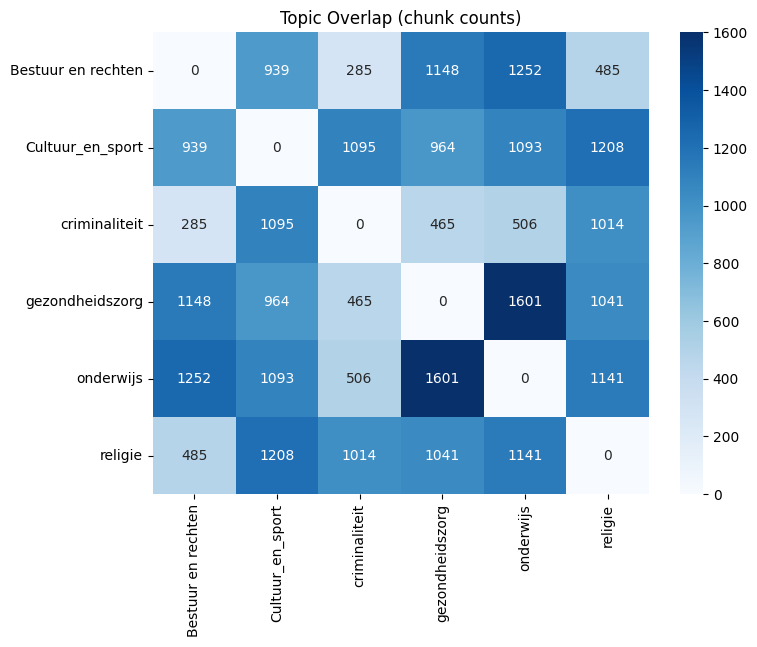

In [42]:
from itertools import combinations
from collections import Counter

df = pd.read_csv("filtered_chunks.csv")


# Compute total assigned chunks per topic
topic_totals = {}
for t in topic_names:
    topic_totals[t] = df['topic'].apply(lambda x: t in parse_topic_list(x)).sum()


# All topic pairs for each chunk
pairs = []
for topics in df['topic'].apply(parse_topic_list):
    if len(topics) > 1:
        pairs.extend(combinations(sorted(topics), 2))

topic_list = list(topic_names)  # Or sorted(list(topic_names)) if you want order
matrix = pd.DataFrame(0, index=topic_list, columns=topic_list)

for topics in df['topic'].apply(parse_topic_list):
    for a, b in combinations(sorted(topics), 2):
        matrix.loc[a, b] += 1
        matrix.loc[b, a] += 1  # Symmetric

print(matrix)

#Overlap count matrix (as you have)
matrix = pd.DataFrame(0, index=topic_names, columns=topic_names)
for topics in df['topic'].apply(parse_topic_list):
    for a, b in combinations(sorted(topics), 2):
        matrix.loc[a, b] += 1
        matrix.loc[b, a] += 1  # Make it symmetric

# Percentage overlap: for each pair (A,B), what % of A’s chunks are also B
perc_matrix = pd.DataFrame('', index=topic_names, columns=topic_names)
for a in topic_names:
    for b in topic_names:
        if topic_totals[a]:
            perc = 100 * matrix.loc[a, b] / topic_totals[a]
            perc_matrix.loc[a, b] = f'{perc:.1f}%'
        else:
            perc_matrix.loc[a, b] = '-'
print(perc_matrix)

# Count how often each topic pair co-occurs
pair_counts = Counter(pairs)
for pair, count in pair_counts.most_common(10):
    print(f"{pair}: {count} chunks")


# How many topics does each chunk have?
df['num_topics'] = df['topic'].apply(lambda x: len(parse_topic_list(x)))
print(df['num_topics'].value_counts())



import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Topic Overlap (chunk counts)")
plt.show()



In [39]:
import os
import ast
import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ===== CONFIG =====
USE_MULTI_LABEL = True                     # False for single-label path
MODEL_NAME = "GroNLP/bert-base-dutch-cased"
COSINE_MIN = 0.1                          # per-topic cosine threshold (cleaned)
COSINE_WEIGHTED_MIN = 0.01                 # per-topic weighted cosine threshold (cleaned)
#MODEL_FOLDER = "model_output"

# ===== PRECONDITIONS =====
assert 'topic_names' in globals() and isinstance(topic_names, (list, tuple)) and len(topic_names) > 0, \
    "topic_names must exist as a non-empty list in the environment."
assert 'train_source' in globals() and isinstance(train_source, pd.DataFrame), \
    "train_source (DataFrame) must exist in the environment."

num_topics = len(topic_names)
topic2idx = {t: i for i, t in enumerate(topic_names)}

# ===== HELPERS =====
def safe_to_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except Exception:
            return []
    return []

def normalize_len(lst, L, fill=0.0):
    lst = list(lst) if isinstance(lst, (list, tuple)) else []
    if len(lst) < L:
        lst = lst + [fill] * (L - len(lst))
    return lst[:L]

def labels_from_topic_pipe(s):
    vec = [0] * num_topics
    if isinstance(s, str) and s.strip():
        for part in s.split('|'):
            p = part.strip()
            if p in topic2idx:
                vec[topic2idx[p]] = 1
    return vec

def labels_all_zero(lst):
    return isinstance(lst, list) and all(int(v) == 0 for v in lst)

# ===== LOAD / COPY =====
df = train_source.copy()

# ===== PER-TOPIC COSINES =====
cosine_list = df['cosine'].apply(safe_to_list)
if cosine_list.map(len).max() == 0:
    df['cosine_per_topic'] = df['cosine'].apply(
        lambda v: [float(v)] * num_topics if pd.notna(v) else [0.0] * num_topics
    )
else:
    df['cosine_per_topic'] = cosine_list.apply(lambda x: normalize_len(x, num_topics, fill=0.0))

df['cosine_weighted'] = df['cosine_weighted'].apply(safe_to_list).apply(
    lambda x: normalize_len(x, num_topics, fill=0.0)
)

# ===== RAW LABELS FROM PIPE COLUMN =====
df['labels_raw'] = df['topic'].apply(labels_from_topic_pipe)

# ===== CHUNK ID =====
df['chunk_id'] = df.apply(lambda r: f"{r['filename']}__{r['chunk_num']}", axis=1)

# ===== PRUNE LABELS BY THRESHOLDS =====
def prune_labels_by_threshold(row):
    labels = list(row['labels_raw'])
    wts = row['cosine_weighted']
    cos = row['cosine_per_topic']
    for i, l in enumerate(labels):
        if l == 1:
            ok_w = float(wts[i]) >= COSINE_WEIGHTED_MIN
            ok_c = float(cos[i]) >= COSINE_MIN
            if not (ok_w and ok_c):
                labels[i] = 0
    return labels

df['labels'] = df.apply(prune_labels_by_threshold, axis=1)

# ===== CAPTURE NO-TOPIC ROWS BEFORE DROPPING =====
no_topic_rows_all = df[df['labels'].apply(labels_all_zero)].copy()
no_topic_rows_all['no_topic'] = True

# ===== KEEP ONLY LABELED ROWS FOR MODELING =====
df_labeled = df[~df['labels'].apply(labels_all_zero)].reset_index(drop=True)

# ===== BALANCING =====
if USE_MULTI_LABEL:
    df_balanced = df_labeled.copy()
else:
    def pick_single_label(row):
        assigned = np.array(row['labels'], dtype=int)
        if assigned.any():
            w = np.array(row['cosine_weighted'], dtype=float)
            w[assigned == 0] = -np.inf
            return int(np.argmax(w))
        return -1

    df_labeled['label'] = df_labeled.apply(pick_single_label, axis=1)
    df_labeled = df_labeled[df_labeled['label'] != -1].reset_index(drop=True)

    value_counts = df_labeled['label'].value_counts()
    if value_counts.empty:
        raise ValueError("No labeled rows remain after pruning; relax thresholds.")

    min_n = value_counts.min()
    balanced_dfs = []
    for lbl in range(num_topics):
        sub = df_labeled[df_labeled['label'] == lbl]
        if len(sub) >= min_n:
            balanced_dfs.append(sub.sample(min_n, random_state=42))

    if not balanced_dfs:
        raise ValueError("Balancing produced no data; check label distribution.")
    df_balanced = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Final dataset size after filtering/balancing: {len(df_balanced)}")

# ===== SPLIT =====
if len(df_balanced) == 0:
    raise ValueError("After filtering, df_balanced is empty. Lower COSINE_MIN / COSINE_WEIGHTED_MIN.")

if USE_MULTI_LABEL:
    train_df, val_df = train_test_split(df_balanced, test_size=0.2, random_state=42)
else:
    train_df, val_df = train_test_split(
        df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['label']
    )

# ===== CLASS WEIGHTS (ROBUST) =====
if USE_MULTI_LABEL:
    train_label_array = np.stack(train_df['labels'].values) if len(train_df) > 0 else np.zeros((0, num_topics))
    N_total = len(train_label_array)
    class_counts = train_label_array.sum(axis=0) if N_total > 0 else np.zeros(num_topics)
    class_weights = (N_total / (num_topics * np.maximum(class_counts, 1))).tolist()
else:
    label_counts = train_df['label'].value_counts().sort_index()
    N_total = int(label_counts.sum())
    denom = np.maximum(label_counts.values, 1)
    class_weights = (N_total / (num_topics * denom)).tolist()

print("Class weights (for loss):", class_weights)

# ===== ADD NO-TOPIC ROWS TO VALIDATION =====
old_val_ids = set(val_df['chunk_id'])
no_topic_new = no_topic_rows_all[~no_topic_rows_all['chunk_id'].isin(old_val_ids)].copy()

# ensure explicit zero labels
no_topic_new['labels'] = [[0] * num_topics] * len(no_topic_new)

n_added = len(no_topic_new)
val_df = pd.concat([val_df, no_topic_new], ignore_index=True).drop_duplicates(subset=["chunk_id"])

print(f"Added {n_added} truly new 'no-topic' rows to validation set.")
print(f"Validation set now has {len(val_df)} rows (including all 'no-topic' rows).")

# ===== INSPECTION TABLE =====
inspection = []
for t_idx, t_name in enumerate(topic_names):
    if USE_MULTI_LABEL:
        train_labels = np.stack(train_df['labels'].values) if len(train_df) > 0 else np.zeros((0, num_topics))
        val_labels = np.stack(val_df['labels'].values) if len(val_df) > 0 else np.zeros((0, num_topics))

        train_count = int(train_labels[:, t_idx].sum()) if train_labels.size else 0
        val_count = int(val_labels[:, t_idx].sum()) if val_labels.size else 0

        train_cw = [row.cosine_weighted[t_idx] for row in train_df.itertuples() if row.labels[t_idx]] if len(train_df) > 0 else []
        val_cw = [row.cosine_weighted[t_idx] for row in val_df.itertuples() if row.labels[t_idx]] if len(val_df) > 0 else []

        train_mean_cw = float(np.mean(train_cw)) if len(train_cw) else float('nan')
        val_mean_cw = float(np.mean(val_cw)) if len(val_cw) else float('nan')
    else:
        train_count = (train_df['label'] == t_idx).sum()
        val_count = (val_df['label'] == t_idx).sum()

        train_mean_cw = np.mean([row.cosine_weighted[t_idx] for row in train_df.itertuples() if row.label == t_idx]) \
                        if train_count > 0 else float('nan')
        val_mean_cw = np.mean([row.cosine_weighted[t_idx] for row in val_df.itertuples() if row.label == t_idx]) \
                      if val_count > 0 else float('nan')

    inspection.append({
        "Topic": t_name,
        "Train": int(train_count),
        "Val": int(val_count),
        "Train Avg Weighted Cosine": round(train_mean_cw, 4) if not np.isnan(train_mean_cw) else None,
        "Val Avg Weighted Cosine": round(val_mean_cw, 4) if not np.isnan(val_mean_cw) else None
    })

inspection_df = pd.DataFrame(inspection)
print("\n=== Topic Breakdown ===")
print(inspection_df.to_string(index=False))

# ===== SAVE META =====
os.makedirs(MODEL_FOLDER, exist_ok=True)
meta_info = {
    "topic_names": topic_names,
    "num_topics": num_topics,
    "cosine_min": COSINE_MIN,
    "cosine_weighted_min": COSINE_WEIGHTED_MIN,
    "class_weights": class_weights,
    "train_size": len(train_df),
    "val_size": len(val_df),
    "topic_counts": inspection_df.to_dict(orient="records")
}
with open(os.path.join(MODEL_FOLDER, "bertje_split_meta.json"), "w", encoding="utf-8") as f:
    json.dump(meta_info, f, indent=2, ensure_ascii=False)
print(f"Saved class weights and meta info to {os.path.join(MODEL_FOLDER, 'bertje_split_meta.json')}")

# ===== SAVE SPLITS =====
print("Train set size:", len(train_df))
print("Validation set size:", len(val_df))

train_path = os.path.join(MODEL_FOLDER, "train_BERTJE_CHUNKS.csv")
val_path = os.path.join(MODEL_FOLDER, "val_BERTJE_CHUNKS.csv")
train_df.to_csv(train_path, index=False, encoding="utf-8")
val_df.to_csv(val_path, index=False, encoding="utf-8")
print(f"Saved train/val splits to {MODEL_FOLDER}")


Final dataset size after filtering/balancing: 3195
Class weights (for loss): [0.3817204301075269, 0.35529608006672225, 0.5011764705882353, 0.4696802646085998, 1.5106382978723405, 0.3120879120879121]
Added 1510 truly new 'no-topic' rows to validation set.
Validation set now has 2149 rows (including all 'no-topic' rows).

=== Topic Breakdown ===
             Topic  Train  Val  Train Avg Weighted Cosine  Val Avg Weighted Cosine
Bestuur en rechten   1116  267                     0.2051                   0.1978
  Cultuur_en_sport   1199  311                     0.0343                   0.0356
     criminaliteit    850  225                     0.0348                   0.0332
   gezondheidszorg    907  204                     0.0374                   0.0353
         onderwijs    282   76                     0.0869                   0.1031
           religie   1365  350                     0.2354                   0.2464
Saved class weights and meta info to Corex_topicdata_policy_v5\bertje_spl

In [40]:
import os, ast, json
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# ===== CONFIG (keep as-is / minimal knobs) =====
USE_MULTI_LABEL = True
MODEL_NAME = "GroNLP/bert-base-dutch-cased"
COSINE_MIN = 0.1
COSINE_WEIGHTED_MIN = 0.01
#MODEL_FOLDER = "model_output"
NO_TOPIC_RATIO = 0.30     # add up to 30% of labeled val size as no-topic

# ===== PRECONDITIONS =====
assert 'topic_names' in globals() and isinstance(topic_names, (list, tuple)) and len(topic_names) > 0
assert 'train_source' in globals() and isinstance(train_source, pd.DataFrame)
num_topics = len(topic_names)
topic2idx = {t:i for i,t in enumerate(topic_names)}

# ===== HELPERS =====
safe_list = lambda v: v if isinstance(v, list) else (ast.literal_eval(v) if isinstance(v,str) else [])
def fit_len(v, L, fill=0.0): v = list(v) if isinstance(v,(list,tuple)) else []; return (v+[fill]*L)[:L]
def labels_from_pipe(s):
    vec = [0]*num_topics
    if isinstance(s,str) and s.strip():
        for p in (x.strip() for x in s.split('|')):
            if p in topic2idx: vec[topic2idx[p]] = 1
    return vec
is_all_zero = lambda x: isinstance(x,list) and all(int(v)==0 for v in x)

# ===== PREP =====
df = train_source.copy()
c_list = df['cosine'].apply(safe_list)
df['cosine_per_topic'] = np.where(
    c_list.map(len).max()==0,
    df['cosine'].apply(lambda v: [float(v)]*num_topics if pd.notna(v) else [0.0]*num_topics),
    c_list.apply(lambda x: fit_len(x, num_topics, 0.0))
)
df['cosine_weighted'] = df['cosine_weighted'].apply(safe_list).apply(lambda x: fit_len(x, num_topics, 0.0))
df['labels_raw'] = df['topic'].apply(labels_from_pipe)
df['chunk_id'] = df.apply(lambda r: f"{r['filename']}__{r['chunk_num']}", axis=1)

# ===== FILTER: count a row toward a topic only if it passes thresholds =====
def gate(row):
    lab = list(row['labels_raw']); w = row['cosine_weighted']; c = row['cosine_per_topic']
    for i, v in enumerate(lab):
        if v==1 and not (float(w[i]) >= COSINE_WEIGHTED_MIN and float(c[i]) >= COSINE_MIN):
            lab[i] = 0
    return lab
df['labels'] = df.apply(gate, axis=1)

# ===== SNAPSHOT NO-TOPIC then keep only labeled for split =====
no_topic_pool = df[df['labels'].apply(is_all_zero)].copy()
no_topic_pool['no_topic'] = True
df_labeled = df[~df['labels'].apply(is_all_zero)].reset_index(drop=True)

# ===== SPLIT (no balancing logic to keep it lean) =====
if USE_MULTI_LABEL:
    df_balanced = df_labeled
else:
    # single-label shortcut: pick max weighted topic among assigned
    def pick_one(row):
        a = np.array(row['labels'], int)
        if a.any():
            w = np.array(row['cosine_weighted'], float); w[a==0] = -np.inf
            return int(np.argmax(w))
        return -1
    df_labeled['label'] = df_labeled.apply(pick_one, axis=1)
    df_balanced = df_labeled[df_labeled['label']!=-1].reset_index(drop=True)

assert len(df_balanced) > 0, "No data after filtering; lower thresholds."
train_df, val_df = train_test_split(df_balanced, test_size=0.2, random_state=42)

# ===== ADD SOME NO-TOPIC TO VALIDATION =====
used = set(pd.concat([train_df[['chunk_id']], val_df[['chunk_id']]]).chunk_id)
pool = no_topic_pool[~no_topic_pool['chunk_id'].isin(used)].copy()
pool['max_w'] = pool['cosine_weighted'].apply(lambda v: float(max(v)) if v else 0.0)
pool = pool.sort_values('max_w', ascending=True)

quota = min(int(NO_TOPIC_RATIO * max(len(val_df),1)), len(pool))
if quota > 0:
    add_nt = pool.head(quota).copy()
    add_nt['labels'] = [[0]*num_topics]*len(add_nt)
    val_df = pd.concat([val_df, add_nt], ignore_index=True).drop_duplicates(subset=['chunk_id'])

# ===== CLASS WEIGHTS =====
if USE_MULTI_LABEL:
    A = np.stack(train_df['labels'].values) if len(train_df)>0 else np.zeros((0,num_topics))
    N = len(A); counts = A.sum(axis=0) if N>0 else np.zeros(num_topics)
    class_weights = (N / (num_topics * np.maximum(counts, 1))).tolist()
else:
    counts = train_df['label'].value_counts().sort_index()
    N = int(counts.sum()); denom = np.maximum(counts.values, 1)
    class_weights = (N / (num_topics * denom)).tolist()

print(f"Final dataset size after filtering: {len(df_balanced)}")
print("Class weights (for loss):", class_weights)
print(f"Validation set now has {len(val_df)} rows (incl. added no-topic).")

# ===== INSPECTION TABLE =====
inspection = []
for i, name in enumerate(topic_names):
    if USE_MULTI_LABEL:
        tr = np.stack(train_df['labels'].values) if len(train_df)>0 else np.zeros((0,num_topics))
        va = np.stack(val_df['labels'].values) if len(val_df)>0 else np.zeros((0,num_topics))
        tcnt = int(tr[:,i].sum()) if tr.size else 0
        vcnt = int(va[:,i].sum()) if va.size else 0
        t_cw = [r.cosine_weighted[i] for r in train_df.itertuples() if r.labels[i]] if len(train_df)>0 else []
        v_cw = [r.cosine_weighted[i] for r in val_df.itertuples() if r.labels[i]] if len(val_df)>0 else []
        t_mean = round(float(np.mean(t_cw)),4) if t_cw else None
        v_mean = round(float(np.mean(v_cw)),4) if v_cw else None
    else:
        tcnt = int((train_df['label']==i).sum()); vcnt = int((val_df['label']==i).sum())
        t_mean = round(float(np.mean([r.cosine_weighted[i] for r in train_df.itertuples() if r.label==i])),4) if tcnt>0 else None
        v_mean = round(float(np.mean([r.cosine_weighted[i] for r in val_df.itertuples() if r.label==i])),4) if vcnt>0 else None
    inspection.append({"Topic": name, "Train": tcnt, "Val": vcnt,
                       "Train Avg Weighted Cosine": t_mean, "Val Avg Weighted Cosine": v_mean})
inspection_df = pd.DataFrame(inspection)
print("\n=== Topic Breakdown ===")
print(inspection_df.to_string(index=False))

# ===== SAVE =====
os.makedirs(MODEL_FOLDER, exist_ok=True)
with open(os.path.join(MODEL_FOLDER, "bertje_split_meta.json"), "w", encoding="utf-8") as f:
    json.dump({
        "topic_names": topic_names,
        "num_topics": num_topics,
        "cosine_min": COSINE_MIN,
        "cosine_weighted_min": COSINE_WEIGHTED_MIN,
        "class_weights": class_weights,
        "train_size": len(train_df),
        "val_size": len(val_df),
        "topic_counts": inspection_df.to_dict(orient="records")
    }, f, indent=2, ensure_ascii=False)

train_df.to_csv(os.path.join(MODEL_FOLDER, "train_BERTJE_CHUNKS.csv"), index=False, encoding="utf-8")
val_df.to_csv(os.path.join(MODEL_FOLDER, "val_BERTJE_CHUNKS.csv"), index=False, encoding="utf-8")
print(f"Saved splits & meta to {MODEL_FOLDER}")


Final dataset size after filtering: 3195
Class weights (for loss): [0.3817204301075269, 0.35529608006672225, 0.5011764705882353, 0.4696802646085998, 1.5106382978723405, 0.3120879120879121]
Validation set now has 830 rows (incl. added no-topic).

=== Topic Breakdown ===
             Topic  Train  Val  Train Avg Weighted Cosine  Val Avg Weighted Cosine
Bestuur en rechten   1116  267                     0.2051                   0.1978
  Cultuur_en_sport   1199  311                     0.0343                   0.0356
     criminaliteit    850  225                     0.0348                   0.0332
   gezondheidszorg    907  204                     0.0374                   0.0353
         onderwijs    282   76                     0.0869                   0.1031
           religie   1365  350                     0.2354                   0.2464
Saved splits & meta to Corex_topicdata_policy_v5


In [46]:
import torch, types
import torch.optim.lr_scheduler as lrs
if not hasattr(lrs, "LRScheduler") and hasattr(lrs, "_LRScheduler"):
    # create a public alias so libs expecting LRScheduler don't crash
    class LRScheduler(lrs._LRScheduler): pass
    lrs.LRScheduler = LRScheduler


In [48]:
import torch, types
import torch.optim.lr_scheduler as lrs
if not hasattr(lrs, "LRScheduler") and hasattr(lrs, "_LRScheduler"):
    # create a public alias so libs expecting LRScheduler don't crash
    class LRScheduler(lrs._LRScheduler): pass
    lrs.LRScheduler = LRScheduler


import os
import json
import torch
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from torch import nn
from sklearn.metrics import classification_report, confusion_matrix

# ====== CONFIG ======
MODEL_NAME = "GroNLP/bert-base-dutch-cased"  # or path to your local checkpoint
META_PATH = "Corex_topicdata_Policy_v5/bertje_split_meta.json"
CHECKPOINT_PATH = "Corex_topicdata_Policy_v5/bertje_policy_checkpoints"  # update if needed
USE_MULTI_LABEL = True  # <-- SET TO FALSE for single-label!

# ====== LOAD DATA ======
train_path = "Corex_topicdata_Policy_v5/train_BERTJE_CHUNKS.csv"
val_path   = "Corex_topicdata_Policy_v5/val_BERTJE_CHUNKS.csv"
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)

# For multi-label: make sure labels column is list of ints (0/1)
if USE_MULTI_LABEL:
    train_df['labels'] = train_df['labels'].apply(eval)  # or ast.literal_eval if safer
    val_df['labels'] = val_df['labels'].apply(eval)
else:
    # Drop rows with NaN in 'label' before casting to int
    train_df = train_df.dropna(subset=['label'])
    val_df = val_df.dropna(subset=['label'])
    train_df['label'] = train_df['label'].astype(int)
    val_df['label'] = val_df['label'].astype(int)

# ====== LOAD LABELS, CLASS WEIGHTS, AND MAPPINGS ======
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)
topic_names = meta["topic_names"]
class_weights = torch.tensor(meta["class_weights"])
num_labels = len(topic_names)

# ====== Convert to HuggingFace Dataset ======
if USE_MULTI_LABEL:
    train_df['labels'] = train_df['labels'].apply(lambda x: [float(i) for i in eval(x)] if isinstance(x, str) else [float(i) for i in x])
    val_df['labels'] = val_df['labels'].apply(lambda x: [float(i) for i in eval(x)] if isinstance(x, str) else [float(i) for i in x])

train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
# ====== Tokenizer ======
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch["chunk_text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# ====== Model ======
# Only use CHECKPOINT_PATH if it contains a config.json (valid HuggingFace checkpoint)
checkpoint_config = os.path.join(CHECKPOINT_PATH, "config.json")
if CHECKPOINT_PATH and os.path.exists(checkpoint_config):
    model_path = CHECKPOINT_PATH
else:
    model_path = MODEL_NAME

model = AutoModelForSequenceClassification.from_pretrained(
    model_path,
    num_labels=num_labels,
    problem_type="multi_label_classification" if USE_MULTI_LABEL else "single_label_classification"
)

# ====== Metrics ======
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if USE_MULTI_LABEL:
        # Multi-label: threshold at 0.5
        probs = torch.sigmoid(torch.tensor(logits)).numpy()
        preds = (probs > 0.5).astype(int)
        labels = labels.astype(int)
        from sklearn.metrics import f1_score, accuracy_score
        f1 = f1_score(labels, preds, average="weighted", zero_division=0)
        acc = accuracy_score(labels, preds)
        return {"accuracy": acc, "f1": f1}
    else:
        preds = np.argmax(logits, axis=1)
        from sklearn.metrics import accuracy_score, f1_score
        return {
            "accuracy": accuracy_score(labels, preds),
            "f1": f1_score(labels, preds, average="weighted"),
        }

# ====== Custom Trainer Subclass ======
from transformers import Trainer

class CustomLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if USE_MULTI_LABEL:
            # Robustly: always cast to float, and move to logits.device!
            labels = labels.float() if hasattr(labels, 'float') else torch.tensor(labels, dtype=torch.float, device=logits.device)
            if labels.device != logits.device:
                labels = labels.to(logits.device)
            loss_fct = nn.BCEWithLogitsLoss(pos_weight=class_weights.to(logits.device))
        else:
            labels = labels.long() if hasattr(labels, 'long') else torch.tensor(labels, dtype=torch.long, device=logits.device)
            if labels.device != logits.device:
                labels = labels.to(logits.device)
            loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


# ====== Training Arguments ======
os.environ["WANDB_DISABLED"] = "true"
training_args = TrainingArguments(
    output_dir= CHECKPOINT_PATH,
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

# ====== Trainer ======
trainer = CustomLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# ====== Train! ======
trainer.train()

# ====== Evaluation ======
eval_results = trainer.predict(val_dataset)

if USE_MULTI_LABEL:
    y_pred = (torch.sigmoid(torch.tensor(eval_results.predictions)).numpy() > 0.5).astype(int)
    y_true = eval_results.label_ids.astype(int)
    print(classification_report(
        y_true,
        y_pred,
        target_names=topic_names,
        zero_division=0
    ))
    # For multi-label, confusion matrices are less informative; can plot per-class stats if desired
else:
    y_pred = np.argmax(eval_results.predictions, axis=1)
    y_true = eval_results.label_ids
    print(classification_report(
        y_true,
        y_pred,
        target_names=topic_names,
        zero_division=0
    ))
    cm = confusion_matrix(y_true, y_pred)
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=topic_names, yticklabels=topic_names, cmap="Blues")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix: Topic Classification")
    plt.show()

print("Done.")

c:\Users\Home\policy-analysis\.conda\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Map:   0%|          | 0/2556 [00:00<?, ? examples/s]

Map:   0%|          | 0/830 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


  0%|          | 0/480 [00:00<?, ?it/s]

...

{'eval_loss': 0.2774401009082794, 'eval_accuracy': 0.27349397590361446, 'eval_f1': 0.6672964754329973, 'eval_runtime': 4.7187, 'eval_samples_per_second': 175.897, 'eval_steps_per_second': 5.51, 'epoch': 2.0}


  0%|          | 0/26 [00:00<?, ?it/s]

{'eval_loss': 0.27082735300064087, 'eval_accuracy': 0.28674698795180725, 'eval_f1': 0.6667593298918254, 'eval_runtime': 4.5945, 'eval_samples_per_second': 180.653, 'eval_steps_per_second': 5.659, 'epoch': 3.0}
{'train_runtime': 173.5298, 'train_samples_per_second': 44.188, 'train_steps_per_second': 2.766, 'train_loss': 0.26181303660074867, 'epoch': 3.0}


  0%|          | 0/26 [00:00<?, ?it/s]

                    precision    recall  f1-score   support

Bestuur en rechten       0.83      0.69      0.75       267
  Cultuur_en_sport       0.79      0.39      0.52       311
     criminaliteit       0.63      0.57      0.60       225
   gezondheidszorg       0.60      0.51      0.55       204
         onderwijs       0.71      0.72      0.72        76
           religie       0.81      0.86      0.83       350

         micro avg       0.74      0.62      0.68      1433
         macro avg       0.73      0.62      0.66      1433
      weighted avg       0.75      0.62      0.67      1433
       samples avg       0.69      0.51      0.56      1433

Done.


In [54]:
# === CREATE & SAVE: run after your Corex stage to produce a reusable save-folder ===
import os
import json
import pickle
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# === CONFIG ===
LOAD_FOLDER = "Corex_topicdata_policy_v5"   # contains metadata, mappings, checkpoints
CHECKPOINT_DIR = os.path.join(LOAD_FOLDER, "bertje_policy_checkpoints")
SAVE_NAME = "Bertje_Policy_v6"              # unique output folder will be created

# --- Load results produced by your Corex/dictionary pipeline ---
RESULTS_CSV = os.path.join(LOAD_FOLDER, "chunk_topics_corex_assignments.csv")
TOPICDATA_JSON = os.path.join(LOAD_FOLDER, "lda_topicdata.json")
train_source = pd.read_csv(RESULTS_CSV)

with open(TOPICDATA_JSON, "r", encoding="utf-8") as f:
    topicdata = json.load(f)
topic_names = topicdata["topic_names"]
topic_word_lists = topicdata["topic_word_lists"]

# === Find latest BERTje checkpoint ===
def find_latest_checkpoint(checkpoint_dir):
    subs = [
        os.path.join(checkpoint_dir, f)
        for f in os.listdir(checkpoint_dir)
        if os.path.isdir(os.path.join(checkpoint_dir, f))
    ]
    subs = sorted(subs, key=os.path.getmtime, reverse=True)
    return subs[0] if subs else checkpoint_dir

latest_checkpoint = find_latest_checkpoint(CHECKPOINT_DIR)
print(f"Using model from: {latest_checkpoint}")

# === Load tokenizer and model ===
tokenizer = BertTokenizer.from_pretrained("GroNLP/bert-base-dutch-cased")
model = BertForSequenceClassification.from_pretrained(latest_checkpoint)
model.eval()

# ---- LABEL PREPARATION (no reconstruction; just readable helpers) ----
import ast

# Convert persisted string like "[False, True, ...]" to list[bool]
train_source['label_bools'] = train_source['topic_assigned'].apply(ast.literal_eval)

# Human-readable names (optional view only; does not change saved originals)
def bools_to_labels(bools):
    return [topic_names[i] for i, val in enumerate(bools) if bool(val)]

train_source['labels'] = train_source['label_bools'].apply(bools_to_labels)

# === Load label encoder and mappings ===
with open(os.path.join(LOAD_FOLDER, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)
with open(os.path.join(LOAD_FOLDER, "label2topic.pickle"), "rb") as f:
    label2topic = pickle.load(f)  # name -> id
with open(os.path.join(LOAD_FOLDER, "topic2label.json"), "r", encoding="utf-8") as f:
    topic2label = json.load(f)    # id(str) -> name

# Map true labels (from labels) to ids (ground-truth used for eval)
texts = train_source['chunk_text'].tolist()
label_lists = train_source['labels'].tolist()
y_true = [[label2topic[label] for label in label_list] for label_list in label_lists]

# === Generate CLS embeddings + predictions + confidences ===
BATCH_SIZE = 16
all_cls_embeds, all_confidences, all_pred_idxs = [], [], []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Embedding + predicting"):
    batch_texts = texts[i:i+BATCH_SIZE]
    inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True, max_length=256, padding=True)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        cls_emb = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred_idxs = np.argmax(probs, axis=1)
        confs = probs[np.arange(len(probs)), pred_idxs]

    all_cls_embeds.append(cls_emb)
    all_confidences.extend(confs)
    all_pred_idxs.extend(pred_idxs)

embeddings = np.vstack(all_cls_embeds)

# === Build DataFrame with predictions (no reconstruction of Corex fields) ===
topic2label = {int(k): v for k, v in topic2label.items()}  # ensure int keys

df = train_source.copy()
df['confidence'] = all_confidences
df['pred_label'] = [topic2label[i] for i in all_pred_idxs]
df['true_topic'] = y_true  # keep as originally derived ids list

# === 2D projection for later visuals ===
perplexity = min(30, max(2, len(embeddings) - 1))
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
reduced = tsne.fit_transform(embeddings)
df['x'] = reduced[:, 0]
df['y'] = reduced[:, 1]

# === Chunk length convenience metric ===
def chunk_length_in_5letter_words(text):
    words = str(text).split()
    return sum(max(1, len(w) // 5) for w in words)

df['chunk_5w_len'] = df['chunk_text'].apply(chunk_length_in_5letter_words)

# === Simple TF-IDF anchor similarity summary (read-only diagnostics) ===
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
topic_anchor_docs = [' '.join(words) for words in topic_word_lists]
tfidf.fit(topic_anchor_docs + df['chunk_text'].astype(str).tolist())
topic_anchor_vecs = tfidf.transform(topic_anchor_docs)

avg_sims_per_topic = []
for i, t in enumerate(topic_names):
    sub = df[df['labels'].apply(lambda L: t in L)]
    if sub.empty:
        avg_sims_per_topic.append(0.0)
        continue
    chunk_vecs = tfidf.transform(sub['chunk_text'].astype(str))
    sims = cosine_similarity(chunk_vecs, topic_anchor_vecs[i])
    avg_sims_per_topic.append(float(np.mean(sims)))

# === Summaries (unchanged logic) ===
def count_topic_keywords(chunk, topic_word_list):
    chunk_tokens = set(str(chunk).lower().split())
    anchors = set(topic_word_list)
    return len(chunk_tokens & anchors)

summary_true = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['labels'].apply(lambda L: t in L)]['chunk_5w_len'].mean() for t in topic_names],
    "avg_cos_sim": avg_sims_per_topic,
    "avg_conf_treshold": [
        df[df['labels'].apply(lambda L: t in L)]['confidence'].mean()
        if not df[df['labels'].apply(lambda L: t in L)].empty else 0
        for t in topic_names
    ],
    "avg_keywords": [
        df[df['labels'].apply(lambda L: t in L)]['chunk_text'].apply(
            lambda txt, i=i: count_topic_keywords(txt, topic_word_lists[i])
        ).mean() for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['labels'].apply(lambda L: t in L)]['filename'].value_counts().idxmax()
        if not df[df['labels'].apply(lambda L: t in L)].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['labels'].apply(lambda L: t in L)]['filename'].value_counts().max()
        if not df[df['labels'].apply(lambda L: t in L)].empty else 0
        for t in topic_names
    ],
})

summary_pred = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['pred_label'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_conf_treshold": [
        df[df['pred_label'] == t]['confidence'].mean()
        if not df[df['pred_label'] == t].empty else 0
        for t in topic_names
    ],
    "avg_keywords": [
        df[df['pred_label'] == t]['chunk_text'].apply(
            lambda txt, i=i: count_topic_keywords(txt, topic_word_lists[i])
        ).mean() for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['pred_label'] == t]['filename'].value_counts().idxmax()
        if not df[df['pred_label'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['pred_label'] == t]['filename'].value_counts().max()
        if not df[df['pred_label'] == t].empty else 0
        for t in topic_names
    ],
})

# === Add your 5 alias columns (NO reconstruction; only copy if present) ===
def maybe_copy(dst_name, src_name):
    if src_name in df.columns:
        df[dst_name] = df[src_name]

maybe_copy("Cor_Topic", "topic_assigned")          # original Corex/dict assignment as saved
maybe_copy("Cor_cosine", "cosine")                 # raw cosine list as saved
maybe_copy("Cor_weightedcosine", "cosine_weighted")# weighted cosine list as saved
maybe_copy("Bertje_pred", "pred_label")            # model predicted label
maybe_copy("Bertje_true", "true_topic")            # ground truth ids list used for eval

# === Save outputs ===
def get_unique_folder(base_name):
    folder = base_name
    v = 1
    while os.path.exists(folder):
        v += 1
        folder = f"{base_name}_v{v}"
    os.makedirs(folder)
    return folder

SAVEFOLDER = get_unique_folder(SAVE_NAME)

df.to_csv(os.path.join(SAVEFOLDER, "df_full.csv"), index=False)
np.save(os.path.join(SAVEFOLDER, "embeddings.npy"), embeddings)
np.save(os.path.join(SAVEFOLDER, "tsne_coords.npy"), reduced)
summary_true.to_csv(os.path.join(SAVEFOLDER, "summary_true.csv"), index=False)
summary_pred.to_csv(os.path.join(SAVEFOLDER, "summary_pred.csv"), index=False)

with open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "wb") as f:
    pickle.dump(label2topic, f)
with open(os.path.join(SAVEFOLDER, "topic2label.pickle"), "wb") as f:
    pickle.dump({int(k): v for k, v in topic2label.items()}, f)
with open(os.path.join(SAVEFOLDER, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)
with open(os.path.join(SAVEFOLDER, "topic_names.json"), "w", encoding="utf-8") as f:
    json.dump(topic_names, f, ensure_ascii=False, indent=2)
with open(os.path.join(SAVEFOLDER, "topic_word_lists.json"), "w", encoding="utf-8") as f:
    json.dump(topic_word_lists, f, ensure_ascii=False, indent=2)

params = {
    "model_checkpoint": latest_checkpoint,
    "base_folder": LOAD_FOLDER,
    "BATCH_SIZE": BATCH_SIZE,
    "tsne_perplexity": perplexity,
    "generated_on": datetime.now().isoformat(),
}
with open(os.path.join(SAVEFOLDER, "script_params.json"), "w") as f:
    json.dump(params, f, indent=2)

print(f"All results saved in: {SAVEFOLDER}")
print("Columns exported for downstream use:", [c for c in ["Cor_Topic","Cor_cosine","Cor_weightedcosine","Bertje_pred","Bertje_true"] if c in df.columns])


Using model from: Corex_topicdata_policy_v5\bertje_policy_checkpoints\checkpoint-480


c:\Users\Home\policy-analysis\.conda\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning:

`clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884

Embedding + predicting: 100%|██████████| 295/295 [14:39<00:00,  2.98s/it]


All results saved in: Bertje_Policy_v6
Columns exported for downstream use: ['Cor_Topic', 'Cor_cosine', 'Cor_weightedcosine', 'Bertje_pred', 'Bertje_true']


In [ ]:
# === LOAD & SANITISE: open a previously saved folder and make it ready for next steps ===
import os
import re
import json
import pickle
import numpy as np
import pandas as pd

# ================== CONFIG ==================
SAVEFOLDER = "Bertje_policy_v5"   # or the new folder created by Script 1
NO_TOPIC = "unknown"

# ================== LOAD ====================
df = pd.read_csv(os.path.join(SAVEFOLDER, "df_full.csv"))
embeddings = np.load(os.path.join(SAVEFOLDER, "embeddings.npy"))
tsne_coords = np.load(os.path.join(SAVEFOLDER, "tsne_coords.npy"))

summary_true = pd.read_csv(os.path.join(SAVEFOLDER, "summary_true.csv"))
summary_pred = pd.read_csv(os.path.join(SAVEFOLDER, "summary_pred.csv"))

with open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "rb") as f:
    label2topic = pickle.load(f)
with open(os.path.join(SAVEFOLDER, "topic2label.pickle"), "rb") as f:
    topic2label = pickle.load(f)
with open(os.path.join(SAVEFOLDER, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

with open(os.path.join(SAVEFOLDER, "topic_names.json"), "r", encoding="utf-8") as f:
    topic_names = json.load(f)
with open(os.path.join(SAVEFOLDER, "topic_word_lists.json"), "r", encoding="utf-8") as f:
    topic_word_lists = json.load(f)

with open(os.path.join(SAVEFOLDER, "script_params.json"), "r", encoding="utf-8") as f:
    script_params = json.load(f)

print("All files successfully loaded.")

# ============== SANITISER (keep things usable; do not invent data) ==============
_num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def _coerce_int_keys(d):
    try:
        return {int(k): v for k, v in d.items()}
    except Exception:
        return {}

def _parse_num_list(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    if pd.isna(x) or x == "":
        return []
    s = str(x).strip()
    if s.startswith("["):
        return [float(v) for v in _num_re.findall(s)]
    if "|" in s:
        return [float(v) for v in s.split("|") if str(v).strip() != ""]
    try:
        return [float(s)]
    except:
        return []

def _pad_trunc(vals, n, fill=0.0):
    vals = list(vals)
    if len(vals) < n:
        vals += [fill] * (n - len(vals))
    elif len(vals) > n:
        vals = vals[:n]
    return vals

def _to_name_list(any_val, topic_names, n_classes):
    # Best-effort re-parse to names; does not fabricate missing topics
    if isinstance(any_val, (list, tuple, np.ndarray)):
        items = list(any_val)
    elif pd.isna(any_val) or any_val == "":
        items = []
    else:
        s = str(any_val).strip()
        if s.startswith("["):
            raw = re.findall(r"'([^']+)'|\"([^\"]+)\"|(-?\d+)", s)
            items = []
            for a, b, c in raw:
                if a:
                    items.append(a)
                elif b:
                    items.append(b)
                elif c:
                    idx = int(c)
                    if 0 <= idx < n_classes:
                        items.append(topic_names[idx])
        elif "|" in s:
            items = [t.strip() for t in s.split("|") if t.strip()]
        else:
            if s.isdigit():
                idx = int(s)
                items = [topic_names[idx]] if 0 <= idx < n_classes else []
            else:
                items = [s]
    out = []
    for it in items:
        if isinstance(it, (int, np.integer)) and 0 <= it < n_classes:
            out.append(topic_names[int(it)])
        else:
            it_str = str(it)
            if it_str in topic_names:
                out.append(it_str)
    return out

# --- 1) Align df/array lengths (trim only; never fabricate) ---
n_df = len(df)
n_emb = embeddings.shape[0] if embeddings.ndim == 2 else len(embeddings)
n_tsne = tsne_coords.shape[0] if tsne_coords.ndim == 2 else len(tsne_coords)
target_n = min(n_df, n_emb, n_tsne)
if (n_df, n_emb, n_tsne) != (target_n, target_n, target_n):
    print(f"WARNING: length mismatch (df={n_df}, emb={n_emb}, tsne={n_tsne}). Trimming to {target_n}.")
    df = df.iloc[:target_n].reset_index(drop=True)
    embeddings = embeddings[:target_n]
    tsne_coords = tsne_coords[:target_n]

# --- 2) Canonical id->label order; keep topic_names as strings in class order ---
id2label_raw = _coerce_int_keys(label2topic)
if id2label_raw:
    id2label = {i: str(id2label_raw[i]) for i in sorted(id2label_raw.keys())}
    topic_names = [id2label[i] for i in sorted(id2label.keys())]
else:
    topic_names = [str(x) for x in topic_names]
    id2label = {i: topic_names[i] for i in range(len(topic_names))}

n_classes = len(topic_names)
topic2label_map = {v: k for k, v in id2label.items()}

# Keep encoder in sync (safe no-op if structure differs)
try:
    if hasattr(label_encoder, "classes_"):
        import numpy as np as _np  # local alias to avoid shadow
        label_encoder.classes_ = _np.array(topic_names, dtype=object)
except Exception:
    pass

# --- 3) Ensure numeric vectors align when present (do not create if missing) ---
for col in ['cosine_weighted', 'cosine', 'topic_probs']:
    if col in df.columns:
        df[col] = df[col].apply(_parse_num_list).apply(lambda xs: _pad_trunc(xs, n_classes, 0.0))

# --- 4) Topic-like columns -> lists of names (when they exist) ---
for col in ['topic', 'topic_assigned', 'topic_list', 'labels', 'true_topic', 'pred_label']:
    if col in df.columns:
        df[col] = df[col].apply(lambda v: _to_name_list(v, topic_names, n_classes) if col != 'pred_label'
                                else (_to_name_list(v, topic_names, n_classes)[0] if _to_name_list(v, topic_names, n_classes) else NO_TOPIC))

# --- 5) Guarantee x,y columns backed by tsne_coords (fill only missing entries) ---
if 'x' not in df.columns or 'y' not in df.columns:
    df['x'] = tsne_coords[:, 0]
    df['y'] = tsne_coords[:, 1]
else:
    if df['x'].isna().any() or df['y'].isna().any():
        maskx = df['x'].isna().values
        masky = df['y'].isna().values
        if maskx.any(): df.loc[maskx, 'x'] = tsne_coords[maskx, 0]
        if masky.any(): df.loc[masky, 'y'] = tsne_coords[masky, 1]

# --- 6) Expose your five alias columns only if their sources exist (no reconstruction) ---
def maybe_copy(dst_name, src_name):
    if src_name in df.columns:
        df[dst_name] = df[src_name]
        return True
    return False

present = []
if maybe_copy("Cor_Topic", "topic_assigned"):           present.append("Cor_Topic")
if maybe_copy("Cor_cosine", "cosine"):                  present.append("Cor_cosine")
if maybe_copy("Cor_weightedcosine", "cosine_weighted"): present.append("Cor_weightedcosine")
if maybe_copy("Bertje_pred", "pred_label"):             present.append("Bertje_pred")
if maybe_copy("Bertje_true", "true_topic"):             present.append("Bertje_true")

print("Alias columns available:", present)

# --- 7) Ready for plotting/next steps (no saving unless you want to persist the sanitised frame) ---
print(
    "Sanitised:",
    f"\n  n_rows={len(df)} n_classes={n_classes}",
    f"\n  example pred_label = {df['pred_label'].head(3).tolist() if 'pred_label' in df.columns else 'N/A'}",
)
# Optional: persist the sanitised df for downstream steps (comment out if not needed)
# df.to_csv(os.path.join(SAVEFOLDER, "df_full_sanitised.csv"), index=False)


In [49]:
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {v:k for k,v in id2label.items()}
print(model.config.id2label == id2label, model.config.label2id == label2id)


NameError: name 'label_names' is not defined

In [8]:
pip show transformers torch accelerate


Name: transformers
Version: 4.53.3
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: c:\Users\Home\policy-analysis\.conda\Lib\site-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: 
---
Name: torch
Version: 2.0.1
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3
Location: c:\Users\Home\policy-analysis\.conda\Lib\site-packages
Requires: filelock, jinja2, networkx, sympy, typing-extensions
Required-by: accelerate, torchaudio, torchvision
---
Name: accelerate
Version:

In [23]:
# After evaluation
import pandas as pd
sigmoid_preds = (1 / (1 + np.exp(-eval_results.predictions)) > 0.5).astype(int)
y_true = eval_results.label_ids

df_pred = pd.DataFrame({
    "text": val_df["chunk_text"].tolist(),
    "true": y_true.tolist(),
    "pred": sigmoid_preds.tolist()
})

# Chunks with >1 true label
multi_label_rows = df_pred[df_pred["true"].apply(lambda x: sum(x)>1)]
# ...and where model predicted more than one label
multi_label_correct = multi_label_rows[
    multi_label_rows.apply(lambda row: all([t<=p for t, p in zip(row['true'], row['pred'])]), axis=1)
]
print(multi_label_correct.head(10))


                                                 text             true  \
0   datum onz referentie leerweg bbl dag schol vie...  [0.0, 1.0, 1.0]   
1   nummer partij bevoegd voornem uit cultuurhisto...  [0.0, 1.0, 1.0]   
3   totaaloverzicht inclusief agentschapp zbo bedr...  [0.0, 1.0, 1.0]   
6   uitgebreid uiteenzet instandhoudingsplicht ver...  [1.0, 1.0, 1.0]   
8   treff adequat beschermingsmaatregel verder bie...  [0.0, 1.0, 1.0]   
9   sociaal jaarverslag bested bijzonder aandacht ...  [0.0, 1.0, 1.0]   
11  bescherm immaterieel erfgoed geregeld ratifica...  [0.0, 1.0, 1.0]   
12  totaallijst feitelijk vaststell begrotingsstat...  [0.0, 1.0, 1.0]   
15  sprak bepal verkoopprijs aandel bewust onvoldo...  [1.0, 1.0, 1.0]   
16  monumentengemeent fgm blijkt thema wederopbouw...  [0.0, 1.0, 1.0]   

         pred  
0   [1, 1, 1]  
1   [1, 1, 1]  
3   [0, 1, 1]  
6   [1, 1, 1]  
8   [0, 1, 1]  
9   [0, 1, 1]  
11  [0, 1, 1]  
12  [0, 1, 1]  
15  [1, 1, 1]  
16  [0, 1, 1]  


**Bertje model evaluation**


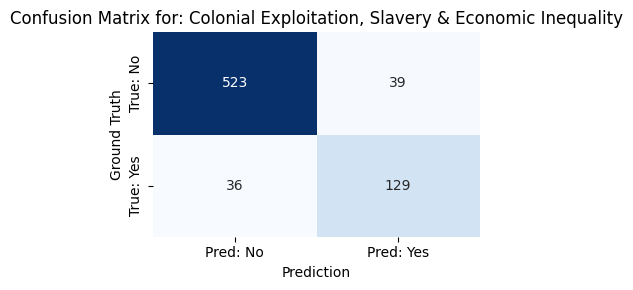

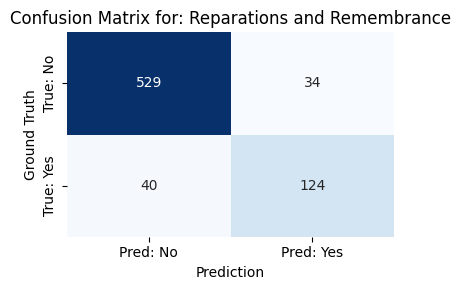

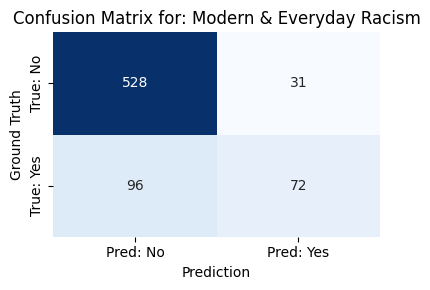

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix
# Compute multilabel confusion matrix
ml_cm = multilabel_confusion_matrix(y_true, y_pred)

for i, topic in enumerate(topic_names):
    cm = ml_cm[i]
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", cbar=False,
                xticklabels=["Pred: No", "Pred: Yes"],
                yticklabels=["True: No", "True: Yes"])
    plt.title(f"Confusion Matrix for: {topic}")
    plt.xlabel("Prediction")
    plt.ylabel("Ground Truth")
    plt.tight_layout()
    plt.show()


In [ ]:
import os
import json
import pickle
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# === CONFIG ===
LOAD_FOLDER = "Corex_topicdata_policy_v6"  # Folder where metadata, mappings, and checkpoints live
CHECKPOINT_DIR = os.path.join(LOAD_FOLDER, "bertje_policy_checkpoints")
Save_name= "Bertje_Policy_v6"

# --- Load results ---
RESULTS_CSV = os.path.join(LOAD_FOLDER, "chunk_topics_corex_assignments.csv")
TOPICDATA_JSON = os.path.join(LOAD_FOLDER, "lda_topicdata.json")
train_source = pd.read_csv(RESULTS_CSV)

# --- Load topic names and wordlists ---
with open(TOPICDATA_JSON, "r", encoding="utf-8") as f:
    topicdata = json.load(f)
topic_names = topicdata["topic_names"]
topic_word_lists = topicdata["topic_word_lists"]


# === Find latest checkpoint inside bertje_policy_checkpoints ===
def find_latest_checkpoint(checkpoint_dir):
    subfolders = [os.path.join(checkpoint_dir, f) for f in os.listdir(checkpoint_dir) if os.path.isdir(os.path.join(checkpoint_dir, f))]
    subfolders = sorted(subfolders, key=os.path.getmtime, reverse=True)
    return subfolders[0] if subfolders else checkpoint_dir

latest_checkpoint = find_latest_checkpoint(CHECKPOINT_DIR)
print(f"Using model from: {latest_checkpoint}")

# === Load tokenizer and model ===
tokenizer = BertTokenizer.from_pretrained("GroNLP/bert-base-dutch-cased")
model = BertForSequenceClassification.from_pretrained(latest_checkpoint)
model.eval()

# ---- LABEL PREPARATION ----
import ast

# Convert string like "[False, True, True]" to Python list
train_source['label_bools'] = train_source['topic_assigned'].apply(ast.literal_eval)

# Convert list of bools to list of topic names
def bools_to_labels(bools):
    return [topic_names[i] for i, val in enumerate(bools) if val]

train_source['labels'] = train_source['label_bools'].apply(bools_to_labels)


# === Load label encoder and topic mappings ===
with open(os.path.join(LOAD_FOLDER, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)
with open(os.path.join(LOAD_FOLDER, "label2topic.pickle"), "rb") as f:
    label2topic = pickle.load(f)
with open(os.path.join(LOAD_FOLDER, "topic2label.json"), "r", encoding="utf-8") as f:
    topic2label = json.load(f)




# This assumes 'train_source' is already loaded into memory.
texts = train_source['chunk_text'].tolist()
label_lists = train_source['labels'].tolist()
y_true = [[label2topic[label] for label in label_list] for label_list in label_lists]




# === Generate BERT embeddings, predictions, and confidences ===
BATCH_SIZE = 16
all_cls_embeds, all_confidences, all_pred_idxs = [], [], []

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Embedding + predicting"):
    batch_texts = texts[i:i+BATCH_SIZE]
    inputs = tokenizer(batch_texts, return_tensors='pt', truncation=True, max_length=256, padding=True)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        cls_emb = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred_idxs = np.argmax(probs, axis=1)
        confs = probs[np.arange(len(probs)), pred_idxs]

    all_cls_embeds.append(cls_emb)
    all_confidences.extend(confs)
    all_pred_idxs.extend(pred_idxs)

embeddings = np.vstack(all_cls_embeds)

# === Build dataframe ===
topic2label = {int(k): v for k, v in topic2label.items()}

df = train_source.copy()
df['confidence'] = all_confidences
df['pred_label'] = [topic2label[i] for i in all_pred_idxs]
df['true_topic'] = y_true

# === t-SNE dimensionality reduction ===
perplexity = min(30, len(embeddings) - 1)
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
reduced = tsne.fit_transform(embeddings)
df['x'] = reduced[:, 0]
df['y'] = reduced[:, 1]

# === Chunk length estimate ===
def chunk_length_in_5letter_words(text):
    words = str(text).split()
    return sum(max(1, len(w) // 5) for w in words)

df['chunk_5w_len'] = df['chunk_text'].apply(chunk_length_in_5letter_words)

# === Cosine similarity to topic anchors ===
tfidf = TfidfVectorizer()
topic_anchor_docs = [' '.join(words) for words in topic_word_lists]
tfidf.fit(topic_anchor_docs + df['chunk_text'].astype(str).tolist())
topic_anchor_vecs = tfidf.transform(topic_anchor_docs)

avg_sims_per_topic = []
for i, t in enumerate(topic_names):
    sub = df[df['true_topic'] == t]
    if sub.empty:
        avg_sims_per_topic.append(0)
        continue
    chunk_vecs = tfidf.transform(sub['chunk_text'].astype(str))
    sims = cosine_similarity(chunk_vecs, topic_anchor_vecs[i])
    avg_sims_per_topic.append(np.mean(sims))

# === Keyword match count ===
def count_topic_keywords(chunk, topic_word_list):
    chunk_tokens = set(str(chunk).lower().split())
    anchors = set(topic_word_list)
    return len(chunk_tokens & anchors)

# === Summary Tables ===
summary_true = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['true_topic'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_cos_sim": avg_sims_per_topic,
    "avg_conf_treshold": [
        df[df['true_topic'] == t]['confidence'].mean() if not df[df['true_topic'] == t].empty else 0
        for t in topic_names
    ],
    "avg_keywords": [
        df[df['true_topic'] == t]['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
        for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['true_topic'] == t]['filename'].value_counts().idxmax() if not df[df['true_topic'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['true_topic'] == t]['filename'].value_counts().max() if not df[df['true_topic'] == t].empty else 0
        for t in topic_names
    ],
})

summary_pred = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['pred_label'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_conf_treshold": [
        df[df['pred_label'] == t]['confidence'].mean() if not df[df['pred_label'] == t].empty else 0
        for t in topic_names
    ],
    "avg_keywords": [
        df[df['pred_label'] == t]['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
        for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['pred_label'] == t]['filename'].value_counts().idxmax() if not df[df['pred_label'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['pred_label'] == t]['filename'].value_counts().max() if not df[df['pred_label'] == t].empty else 0
        for t in topic_names
    ],
})

# === Save outputs ===
def get_unique_folder(base_name):
    folder = base_name
    version = 1
    while os.path.exists(folder):
        version += 1
        folder = f"{base_name}_v{version}"
    os.makedirs(folder)
    return folder

SAVEFOLDER = get_unique_folder(Save_name)

df.to_csv(os.path.join(SAVEFOLDER, "df_full.csv"), index=False)
np.save(os.path.join(SAVEFOLDER, "embeddings.npy"), embeddings)
np.save(os.path.join(SAVEFOLDER, "tsne_coords.npy"), reduced)
summary_true.to_csv(os.path.join(SAVEFOLDER, "summary_true.csv"), index=False)
summary_pred.to_csv(os.path.join(SAVEFOLDER, "summary_pred.csv"), index=False)

with open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "wb") as f:
    pickle.dump(label2topic, f)
with open(os.path.join(SAVEFOLDER, "topic2label.pickle"), "wb") as f:
    pickle.dump(topic2label, f)
with open(os.path.join(SAVEFOLDER, "label_encoder.pkl"), "wb") as f:
    pickle.dump(label_encoder, f)
with open(os.path.join(SAVEFOLDER, "topic_names.json"), "w", encoding="utf-8") as f:
    json.dump(topic_names, f, ensure_ascii=False, indent=2)
with open(os.path.join(SAVEFOLDER, "topic_word_lists.json"), "w", encoding="utf-8") as f:
    json.dump(topic_word_lists, f, ensure_ascii=False, indent=2)

params = {
    "model_checkpoint": latest_checkpoint,
    "base_folder": LOAD_FOLDER,
    "BATCH_SIZE": BATCH_SIZE,
    "tsne_perplexity": perplexity,
    "generated_on": datetime.now().isoformat(),
}
with open(os.path.join(SAVEFOLDER, "script_params.json"), "w") as f:
    json.dump(params, f, indent=2)

print(f"All results saved in: {SAVEFOLDER}")


Using model from: Corex_topicdata_policy_v5\bertje_policy_checkpoints\checkpoint-480


c:\Users\Home\policy-analysis\.conda\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Embedding + predicting: 100%|██████████| 295/295 [15:04<00:00,  3.07s/it]


All results saved in: Bertje_Policy_v5


In [3]:
print(df['cosine_weighted'].iloc[0])
print(type(df['cosine_weighted'].iloc[0]))


[0.34644711940374345, 0.0, 0.0]
<class 'str'>


In [2]:
import os
import json
import pickle
import numpy as np
import pandas as pd

# ================== CONFIG ==================
SAVEFOLDER = "Bertje_policy_v5"

# ================== LOAD ====================
df = pd.read_csv(os.path.join(SAVEFOLDER, "df_full.csv"))

# (Optional/context artifacts; not used to build the 5 columns, just loaded in case you need them later)
try:
    embeddings = np.load(os.path.join(SAVEFOLDER, "embeddings.npy"))
except Exception: embeddings = None
try:
    tsne_coords = np.load(os.path.join(SAVEFOLDER, "tsne_coords.npy"))
except Exception: tsne_coords = None
try:
    summary_true = pd.read_csv(os.path.join(SAVEFOLDER, "summary_true.csv"))
except Exception: summary_true = None
try:
    summary_pred = pd.read_csv(os.path.join(SAVEFOLDER, "summary_pred.csv"))
except Exception: summary_pred = None
try:
    with open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "rb") as f:
        label2topic = pickle.load(f)
except Exception: label2topic = None
try:
    with open(os.path.join(SAVEFOLDER, "topic2label.pickle"), "rb") as f:
        topic2label = pickle.load(f)
except Exception: topic2label = None
try:
    with open(os.path.join(SAVEFOLDER, "label_encoder.pkl"), "rb") as f:
        label_encoder = pickle.load(f)
except Exception: label_encoder = None
try:
    with open(os.path.join(SAVEFOLDER, "topic_names.json"), "r", encoding="utf-8") as f:
        topic_names = json.load(f)
except Exception: topic_names = None
try:
    with open(os.path.join(SAVEFOLDER, "topic_word_lists.json"), "r", encoding="utf-8") as f:
        topic_word_lists = json.load(f)
except Exception: topic_word_lists = None

print("Loaded df_full.csv. (Other artifacts loaded if available; none are used to compute outputs here.)")

# ================== COLUMN MAPPING (NO RECONSTRUCTION) ==================
# We DO NOT compute, coerce, or fall back from any other column.
# We only pass through exact columns if they exist. Otherwise NaN.

source_map = {
    "Cor_Topic": "topic_assigned",     # expected CorEx/dictionary assignment (names or ids as originally saved)
    "Cor_cosine": "cosine",            # expected raw cosine similarities (list/array as saved)
    "Cor_weightedcosine": "cosine_weighted",  # expected weighted cosine (list/array as saved)
    "Bertje_pred": "pred_label",       # expected model-predicted label (already saved)
    "Bertje_true": "true_topic",       # expected ground-truth used during model eval (already saved)
}

out = pd.DataFrame(index=df.index)
missing = []

for out_col, src_col in source_map.items():
    if src_col in df.columns:
        out[out_col] = df[src_col]
    else:
        out[out_col] = pd.NA
        missing.append((out_col, src_col))

# ================== REPORT ==================
print("=== Output columns present ===")
for k, v in source_map.items():
    print(f"{k:<22} <- {v}  ({'FOUND' if v in df.columns else 'MISSING'})")

if missing:
    print("\nWARNING: The following requested outputs are NaN because their source columns were not found:")
    for out_col, src_col in missing:
        print(f" - {out_col} (expected source: '{src_col}')")

# Optionally save
out_path = os.path.join(SAVEFOLDER, "df_minimal_no_recon.csv")
out.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")


Loaded df_full.csv. (Other artifacts loaded if available; none are used to compute outputs here.)
=== Output columns present ===
Cor_Topic              <- topic_assigned  (FOUND)
Cor_cosine             <- cosine  (FOUND)
Cor_weightedcosine     <- cosine_weighted  (FOUND)
Bertje_pred            <- pred_label  (FOUND)
Bertje_true            <- true_topic  (FOUND)

Saved: Bertje_policy_v5\df_minimal_no_recon.csv


In [3]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd

# ================== CONFIG ==================
SAVEFOLDER = "Bertje_policy_v5"
NO_TOPIC = "unknown"  # matches your plotting code

# ================== LOAD ====================
df = pd.read_csv(os.path.join(SAVEFOLDER, "df_full.csv"))
embeddings = np.load(os.path.join(SAVEFOLDER, "embeddings.npy"))
tsne_coords = np.load(os.path.join(SAVEFOLDER, "tsne_coords.npy"))

summary_true = pd.read_csv(os.path.join(SAVEFOLDER, "summary_true.csv"))
summary_pred = pd.read_csv(os.path.join(SAVEFOLDER, "summary_pred.csv"))

with open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "rb") as f:
    label2topic = pickle.load(f)
with open(os.path.join(SAVEFOLDER, "topic2label.pickle"), "rb") as f:
    topic2label = pickle.load(f)
with open(os.path.join(SAVEFOLDER, "label_encoder.pkl"), "rb") as f:
    label_encoder = pickle.load(f)

with open(os.path.join(SAVEFOLDER, "topic_names.json"), "r", encoding="utf-8") as f:
    topic_names = json.load(f)  # may be numbers or strings
with open(os.path.join(SAVEFOLDER, "topic_word_lists.json"), "r", encoding="utf-8") as f:
    topic_word_lists = json.load(f)

with open(os.path.join(SAVEFOLDER, "script_params.json"), "r", encoding="utf-8") as f:
    script_params = json.load(f)

print("All files successfully loaded.")

# ============== SANITISER (force NAMES and equal lengths) ==============
_num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def _coerce_int_keys(d):
    try:
        return {int(k): v for k, v in d.items()}
    except Exception:
        return {}

def _parse_num_list(x):
    if isinstance(x, (list, tuple, np.ndarray)):
        vals = list(x)
    elif pd.isna(x) or x == "":
        vals = []
    else:
        s = str(x).strip()
        if s.startswith("["):
            vals = [float(v) for v in _num_re.findall(s)]
        elif "|" in s:
            vals = [float(v) for v in s.split("|") if str(v).strip() != ""]
        else:
            try: vals = [float(s)]
            except: vals = []
    return vals

def _pad_trunc(vals, n, fill=0.0):
    vals = list(vals)
    if len(vals) < n: vals += [fill]*(n-len(vals))
    elif len(vals) > n: vals = vals[:n]
    return vals

def _to_name_list(any_val, topic_names, n_classes):
    """Return list of VALID topic NAMES from indices/names/stringified lists."""
    if isinstance(any_val, (list, tuple, np.ndarray)):
        items = list(any_val)
    elif pd.isna(any_val) or any_val == "":
        items = []
    else:
        s = str(any_val).strip()
        if s.startswith("["):
            raw = re.findall(r"'([^']+)'|\"([^\"]+)\"|(-?\d+)", s)
            items = []
            for a,b,c in raw:
                if a: items.append(a)
                elif b: items.append(b)
                elif c:
                    idx = int(c)
                    if 0 <= idx < n_classes: items.append(topic_names[idx])
        elif "|" in s:
            items = [t.strip() for t in s.split("|") if t.strip()]
        else:
            if s.isdigit():
                idx = int(s)
                items = [topic_names[idx]] if 0 <= idx < n_classes else []
            else:
                items = [s]
    out = []
    for it in items:
        if isinstance(it, (int, np.integer)) and 0 <= it < n_classes:
            out.append(topic_names[int(it)])
        else:
            it_str = str(it)
            if it_str in topic_names:
                out.append(it_str)
    return out

# --- 1) Align df/arrays lengths (trim to min) ---
n_df = len(df)
n_emb = embeddings.shape[0] if embeddings.ndim == 2 else len(embeddings)
n_tsne = tsne_coords.shape[0] if tsne_coords.ndim == 2 else len(tsne_coords)
target_n = min(n_df, n_emb, n_tsne)
if (n_df, n_emb, n_tsne) != (target_n, target_n, target_n):
    print(f"WARNING: length mismatch (df={n_df}, emb={n_emb}, tsne={n_tsne}). Trimming to {target_n}.")
    df = df.iloc[:target_n].reset_index(drop=True)
    embeddings = embeddings[:target_n]
    tsne_coords = tsne_coords[:target_n]

# --- 2) Build canonical id2label and FORCE topic_names to strings in class order ---
id2label_raw = _coerce_int_keys(label2topic)
if id2label_raw:
    # force values to strings, then order by id
    id2label = {i: str(id2label_raw[i]) for i in sorted(id2label_raw.keys())}
    topic_names = [id2label[i] for i in sorted(id2label.keys())]
else:
    # fallback: take topic_names.json and force to strings
    topic_names = [str(x) for x in topic_names]
    id2label = {i: topic_names[i] for i in range(len(topic_names))}

# Now topic_names is DEFINITELY a list[str] in class-index order
n_classes = len(topic_names)
topic2label = {v: k for k, v in id2label.items()}  # str->int

# keep label_encoder aligned (not used by your plots, but safe)
try:
    if hasattr(label_encoder, "classes_"):
        label_encoder.classes_ = np.array(topic_names, dtype=object)
except Exception:
    pass

# --- 3) Equal-length numeric vectors ---
for col in ['cosine_weighted', 'cosine', 'topic_probs']:
    if col in df.columns:
        df[col] = df[col].apply(_parse_num_list).apply(lambda xs: _pad_trunc(xs, n_classes, 0.0))

# --- 4) Topic-like columns -> NAMES (lists of names) ---
for col in ['topic', 'topic_assigned', 'topic_list', 'labels', 'topic_assigned']:
    if col in df.columns:
        df[col] = df[col].apply(lambda v: _to_name_list(v, topic_names, n_classes))

# Ensure 'true_topic' is an alias for 'topic_assigned' (as list of names)
df['true_topic'] = df['topic_assigned']

# --- 5) Predicted labels -> name (single) + list of names ---
def _make_pred_names(row):
    if 'pred_label' in row and pd.notna(row['pred_label']):
        names = _to_name_list(row['pred_label'], topic_names, n_classes)
        if names: return names
    for candidate in ['labels', 'topic_assigned', 'topic']:
        if candidate in row and row[candidate]:
            names = _to_name_list(row[candidate], topic_names, n_classes)
            if names: return names
    cw = row.get('cosine_weighted', [])
    if isinstance(cw, list) and len(cw) == n_classes and cw:
        i = int(np.argmax(cw))
        return [topic_names[i]]
    return [NO_TOPIC]

df['pred_label_list'] = df.apply(_make_pred_names, axis=1)
df['pred_label'] = df['pred_label_list'].apply(lambda xs: xs[0] if xs else NO_TOPIC)

# --- 6) Confidence (keep or derive) ---
if 'confidence' in df.columns:
    df['confidence'] = pd.to_numeric(df['confidence'], errors='coerce')
else:
    df['confidence'] = df['cosine_weighted'].apply(lambda xs: max(xs) if xs else np.nan)

# --- 7) Ensure x,y exist and align with tsne_coords ---
if 'x' not in df.columns or 'y' not in df.columns:
    df['x'] = tsne_coords[:, 0]
    df['y'] = tsne_coords[:, 1]
else:
    if df['x'].isna().any() or df['y'].isna().any():
        maskx = df['x'].isna().values
        masky = df['y'].isna().values
        if maskx.any(): df.loc[maskx, 'x'] = tsne_coords[maskx, 0]
        if masky.any(): df.loc[masky, 'y'] = tsne_coords[masky, 1]

# --- 8) FINAL GUARANTEES for your plotting code ---
# topic_names: list[str]
# df['cosine_weighted']: list[float] length == len(topic_names)
# df['true_topic']: list[str] (names)
# df['pred_label']: str (name)

print(
    "Sanitised:",
    f"\n  n_rows={len(df)} n_classes={n_classes}",
    f"\n  topic_names (strings) = {topic_names}",
    f"\n  pred_label example    = {df['pred_label'].head(3).tolist()}",
)


All files successfully loaded.
Sanitised: 
  n_rows=4705 n_classes=6 
  topic_names (strings) = ['Bestuur en rechten', 'Cultuur_en_sport', 'criminaliteit', 'gezondheidszorg', 'onderwijs', 'religie'] 
  pred_label example    = ['criminaliteit', 'Bestuur en rechten', 'criminaliteit']


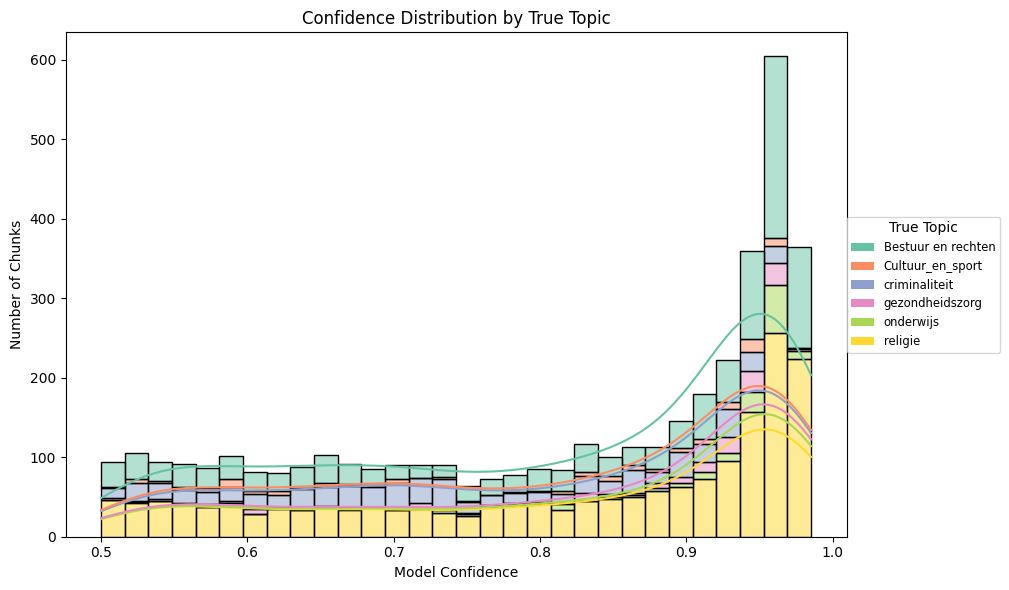

In [32]:
# =========================
# FILTERS (set as needed)
# =========================
# Which label field to filter on for topics: "main", "pred", or "true"
TOPIC_FILTER_SOURCE = "true"          # "main" | "pred" | "true"
TOPIC_FILTER_VALUES = []              # e.g., ["Reparations and Remembrance"]

# Document types to keep (empty = no filter)
DOC_TYPES_FILTER = []                 # e.g., ["Kamerstuk", "Nota", "Wetsvoorstel"]

# Year filter (any of the forms below). Use only one:
YEAR_MIN, YEAR_MAX = None, None       # e.g., 2015, 2024  (inclusive range); None to skip
YEAR_IN = []                          # e.g., [2019, 2020, 2021] (takes precedence over range if set)

# Confidence thresholds PER MAIN TOPIC (row-wise). If a row's main_topic is present here,
# keep it only if df['confidence'] >= that topic's threshold. Leave {} to disable.
# General confidence threshold (set to None to disable)
CONFIDENCE_MIN = 0.5  # e.g., 0.5

CONFIDENCE_MIN_BY_TOPIC = {}  # keep for compatibility, but not used

# Apply general confidence filter if set
if CONFIDENCE_MIN is not None:
    df_filt = df_filt[df_filt['confidence'] >= CONFIDENCE_MIN]

# =========================

import numpy as np
import pandas as pd

# Ensure helper conversions already defined earlier
# safe_to_list, topic_names, etc. assumed to exist per your notebook

def safe_to_list(val):
    if isinstance(val, list):
        return val
    if pd.isna(val) or val is None:
        return []
    if isinstance(val, str):
        try:
            # Try to parse string representation of list
            import ast
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass
        # fallback: split by comma
        return [v.strip() for v in val.split(",") if v.strip()]
    return list(val) if hasattr(val, '__iter__') and not isinstance(val, (str, bytes)) else [val]

# --- Ensure basics are prepared (from your snippet) ---
df['cosine_weighted'] = df['cosine_weighted'].apply(safe_to_list)
df['true_topic'] = df['true_topic'].apply(safe_to_list)

if 'main_topic' not in df.columns:
    df['main_topic'] = df['cosine_weighted'].apply(
        lambda x: topic_names[np.argmax(x)] if isinstance(x, list) and len(x) == len(topic_names) else "unknown"
    )

if 'true_topic_single' not in df.columns:
    df['true_topic_single'] = df['true_topic'].apply(lambda x: x[0] if x else "unknown")

if 'pred_topic_single' not in df.columns and 'pred_label' in df.columns:
    df['pred_topic_single'] = df['pred_label']

# --- Add a short preview of chunk_text for tooltips ---
def make_preview(text, max_chars=60):
    s = str(text) if not pd.isna(text) else ""
    s = " ".join(s.split())               # collapse whitespace/newlines
    return s if len(s) <= max_chars else s[:max_chars-1].rstrip() + "…"

df["chunk_preview"] = df_filt.get("chunk_text", "").apply(make_preview)


# ------------- APPLY FILTERS -------------
df_filt = df.copy()

# Topic filter
if TOPIC_FILTER_VALUES:
    if TOPIC_FILTER_SOURCE == "main":
        df_filt = df_filt[df_filt['main_topic'].astype(str).isin(TOPIC_FILTER_VALUES)]
    elif TOPIC_FILTER_SOURCE == "pred":
        df_filt = df_filt[df_filt['pred_topic_single'].astype(str).isin(TOPIC_FILTER_VALUES)]
    elif TOPIC_FILTER_SOURCE == "true":
        # match against true_topic_single (single label) and also allow list in 'true_topic'
        mask_single = df_filt['true_topic_single'].astype(str).isin(TOPIC_FILTER_VALUES)
        mask_list = df_filt['true_topic'].apply(lambda lst: any(t in TOPIC_FILTER_VALUES for t in (lst if isinstance(lst, list) else [])))
        df_filt = df_filt[mask_single | mask_list]

# Document_type filter
if DOC_TYPES_FILTER and 'Document_type' in df_filt.columns:
    df_filt = df_filt[df_filt['document_type'].astype(str).isin(DOC_TYPES_FILTER)]

# Year filter
if 'Year' in df_filt.columns:
    if YEAR_IN:
        df_filt = df_filt[df_filt['year'].isin(YEAR_IN)]
    else:
        if YEAR_MIN is not None:
            df_filt = df_filt[df_filt['year'] >= YEAR_MIN]
        if YEAR_MAX is not None:
            df_filt = df_filt[df_filt['year'] <= YEAR_MAX]

# Confidence-by-main-topic filter
if CONFIDENCE_MIN_BY_TOPIC:
    def keep_row(row):
        mt = str(row.get('main_topic', 'unknown'))
        thr = CONFIDENCE_MIN_BY_TOPIC.get(mt, None)
        if thr is None:
            return True  # no threshold for this topic
        try:
            return float(row.get('confidence', np.nan)) >= float(thr)
        except Exception:
            return False
    df_filt = df_filt[df_filt.apply(keep_row, axis=1)]


# Apply general confidence filter if set
if CONFIDENCE_MIN is not None:
    df_filt = df_filt[df_filt['confidence'] >= CONFIDENCE_MIN]




# ------------- END FILTERS -------------

# --- Rebuild tooltip on filtered set ---
def tooltip_text(row):
    if isinstance(row['cosine_weighted'], list):
        topic_conf = [
            f"{topic_names[i]}: {round(score, 2)}"
            for i, score in enumerate(row['cosine_weighted'])
            if score > 0
        ]
        return "\n".join(topic_conf)
    return ""

df_filt['tooltip'] = df_filt.apply(tooltip_text, axis=1)

# =========================
# PLOTTING (use df_filt)
# =========================
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Plotly scatter with main topic coloring + tooltips (uses preview)
fig = px.scatter(
    df_filt,
    x='x', y='y',
    color='main_topic',
    hover_data={
        'filename': True,
        'main_topic': True,
        'chunk_preview': True,  # <= short segment here
        'tooltip': True,        # your topic/score list
        'x': False, 'y': False,
    },
    title="Chunks Colored by Most Likely Topic (with Tooltips)"
)
fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.show()

# Predicted labels scatter (uses preview instead of full text)
fig_pred = px.scatter(
    df_filt,
    x='x', y='y',
    color='pred_topic_single',
    hover_data={
        'chunk_preview': True,          # <= short segment here
        'pred_topic_single': True,
        'confidence': True
    },
    title="Predicted Topic Labels"
)
fig_pred.update_traces(marker=dict(size=6, opacity=0.7))
fig_pred.show()

# Confidence strength map (uses preview)
fig_conf = px.scatter(
    df_filt,
    x='x', y='y',
    color='confidence',
    color_continuous_scale='Viridis',
    hover_data={
        'chunk_preview': True,          # <= short segment here
        'pred_topic_single': True,
        'confidence': True
    },
    title="Prediction Strength (Confidence Score)"
)
fig_conf.update_traces(marker=dict(size=6, opacity=0.8))
fig_conf.show()


# Confidence distribution per TRUE topic
df_plot = df_filt[['confidence', 'main_topic']].copy()
df_plot['confidence'] = pd.to_numeric(df_plot['confidence'], errors='coerce')
df_plot = df_plot.dropna(subset=['confidence'])

counts = df_plot.groupby(df_plot['main_topic'].astype(str))['confidence'].size()
valid_topics = [t for t, c in counts.items() if c >= 2]

df_kde = df_plot[df_plot['main_topic'].astype(str).isin(valid_topics)].copy()
df_kde['main_topic'] = df_kde['main_topic'].astype(str)

if 'topic_names' in globals() and isinstance(topic_names, list):
    hue_order = [t for t in topic_names if t in set(valid_topics)]
else:
    hue_order = valid_topics

palette_colors = sns.color_palette("Set2", n_colors=len(hue_order))
palette_map = {lab: col for lab, col in zip(hue_order, palette_colors)}

if not df_kde.empty and len(hue_order) > 0:
    plt.figure(figsize=(12, 6))
    sns.histplot(
        data=df_kde,
        x='confidence',
        hue='main_topic',
        bins=30,
        kde=True,
        multiple='stack',
        palette=palette_map,
        hue_order=hue_order
    )
    plt.title("Confidence Distribution by True Topic")
    plt.xlabel("Model Confidence")
    plt.ylabel("Number of Chunks")

    handles = [Patch(facecolor=palette_map[k], label=k) for k in hue_order]
    plt.legend(
        handles=handles,
        title="True Topic",
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        borderaxespad=0.,
        fontsize='small',
        title_fontsize='medium',
        frameon=True
    )
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()
else:
    print("No valid topics with at least 2 samples for confidence distribution plot.")


In [6]:
print(df['pred_label'].iloc[0])
print(type(df['pred_label'].iloc[0]))
print(len(df['pred_label'].iloc[0]))
print(topic_names)
print(len(topic_names))


[]
<class 'list'>
0
['Colonial Exploitation, Slavery & Economic Inequality', 'Reparations and Remembrance', 'Modern & Everyday Racism']
3


In [48]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
  # Increase to 300 chars (or any large number)

# Ensure all lists are the same length
min_len = min(len(confidences), len(texts), len(true_labels), len(pred_labels))
df = pd.DataFrame({
    'confidence': confidences[:min_len],
    'text': texts[:min_len],
    'true_label': true_labels[:min_len],
    'pred_label': pred_labels[:min_len]
})

# Sort by confidence
high_conf_threshold = df['confidence'].quantile(0.10)
df_high = df[df['confidence'] >= high_conf_threshold]
print(df_high[['confidence', 'true_label', 'pred_label', 'text']])



NameError: name 'confidences' is not defined

In [52]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# --- TF-IDF Transformation ---
vectorizer = TfidfVectorizer(max_features=2000, stop_words=list(all_stopwords))
X_tfidf = vectorizer.fit_transform(df['chunk_text'])

# --- Dimensionality Reduction ---
reducer = umap.UMAP(random_state=42)
X_umap = reducer.fit_transform(X_tfidf)

# --- Add coordinates to DataFrame ---
df['x_umap'] = X_umap[:, 0]
df['y_umap'] = X_umap[:, 1]

# --- Plot 1: True Labels ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='x_umap', y='y_umap',
    hue='true_label_single',
    palette='tab10',
    alpha=0.6,
    s=30
)
plt.title("2D Scatterplot of Chunks by True Topic")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Plot 2: Predicted Labels ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='x_umap', y='y_umap',
    hue='pred_label',
    palette='tab10',
    alpha=0.6,
    s=30
)
plt.title("2D Scatterplot of Chunks by Predicted Topic")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


c:\Users\Home\policy-analysis\.conda\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning:

Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['eilanden'] not in stop_words.

c:\Users\Home\policy-analysis\.conda\Lib\site-packages\umap\umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



ValueError: Could not interpret value `true_label_single` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

##Visual

In [139]:
# Folder and config
SOURCE_FOLDER = r"C:\Users\Home\policy-analysis\Policyarchive_text\jaarverslagen\2015\jaarverslag-beheer-staatsdeelnemingen-2014"  # Original texts
SAVEFOLDER = "bertje_slavery-policy\checkpoint-219"
CHUNK_SIZE = 300  # words per chunk
target_file = "jaarverslag-beheer-staatsdeelnemingen-2014.32.txt"

HIGHLIGHT_COLORS = [
    "#fffbcc",  # butter
    "#eaf9fd",  # cloud blue
    "#eaffea",  # hint of mint
    "#fff0fa",  # soft pink
    "#fff3e6",  # cream
]

# Load outputs
import os, json, pickle
import pandas as pd
import numpy as np

df = pd.read_csv(os.path.join(SAVEFOLDER, "df_full.csv"))
label2topic = pickle.load(open(os.path.join(SAVEFOLDER, "label2topic.pickle"), "rb"))
topic_names = json.load(open(os.path.join(SAVEFOLDER, "topic_names.json"), encoding="utf-8"))

# Make sure the order is consistent (lowest label gets first color)
import numpy as np

# Find all unique labels in your df and assign colors accordingly
unique_labels = sorted(df['label'].unique())
label2color = {label: HIGHLIGHT_COLORS[i % len(HIGHLIGHT_COLORS)] for i, label in enumerate(unique_labels)}

# Map label integer to topic name
label2topic = df[['label', 'pred_label']].drop_duplicates().set_index('label')['pred_label'].to_dict()




def highlight_chunks_in_text(
    text, chunk_labels, chunk_confidence, label2topic, label2color, chunk_size=300
):
    words = text.split()
    html = ""
    for i, (label, conf) in enumerate(zip(chunk_labels, chunk_confidence)):
        chunk_words = words[i*chunk_size : (i+1)*chunk_size]
        chunk_text = " ".join(chunk_words)
        color = label2color[label]
        topic_name = label2topic[label]
        tooltip = f"Topic: {topic_name}<br>Confidence: {conf:.2f}"
        html += (
            f'<span style="background:{color};color:#111;'
            f'padding:2px 6px;border-radius:6px;margin:2px;'
            f'border:1px solid #eee;" title="{tooltip}">'
            f'{chunk_text}</span> '
        )
    return html




chunks = df[df['filename'] == target_file].sort_values('chunk_num')
chunk_labels = chunks['label'].astype(int).tolist()
chunk_confidence = chunks['confidence'].tolist()

with open(os.path.join(SOURCE_FOLDER, target_file), encoding='utf-8') as f:
    original_text = f.read().replace('\n', ' ')

html = highlight_chunks_in_text(
    original_text,
    chunk_labels,
    chunk_confidence,
    label2topic,
    label2color,
    chunk_size=300
)

from IPython.display import display, HTML
display(HTML(html))
